<a href="https://colab.research.google.com/github/adharshraj77/FIFA_Anlysis/blob/main/FIFA_EDAnlysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Phase 1 : Foundational EDA

# Explotary Data Analysis

## 🧾 Part 1: Foundational Data Health Checks & Technical Understanding

### ✅ Objective:
Ensure the dataset is clean, consistent, and statistically sound before modeling. This phase focuses on validating structure, removing technical issues, and building intuition about the data.

## ✅ Step 1: Dataset Overview
Purpose: Understand the structure and content of the dataset.

1.Display dataset shape (rows, columns)

2.Inspect data types and sample rows

3.Check for duplicated rows or IDs

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/fifa20_feature.csv')
df.head()


,short_name,age,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,LWB,RB,RM,RW,RWB,ST,tenure_years,log_value_eur,log_wage_eur,log_release_clause_eur
0,L. Messi,32,170,72,Argentina,FC Barcelona,94,94,95500000,565000,...,0,0,0,1,0,1,17.0,18.374637,13.244583,19.092604
1,Cristiano Ronaldo,34,187,83,Portugal,Juventus,93,93,58500000,405000,...,0,0,0,0,0,1,4.0,17.884537,12.911645,18.385054
2,Neymar Jr,27,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,...,0,0,0,0,0,0,5.0,18.474222,12.577640,19.089535
3,J. Oblak,26,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,...,0,0,0,0,0,0,9.0,18.165789,11.736077,18.919636
4,E. Hazard,28,175,74,Belgium,Real Madrid,91,91,90000000,470000,...,0,0,0,0,0,0,5.0,18.315320,13.060490,19.033160


In [ ]:
# ✅ Basic Shape and Sample
print("📊 Dataset Shape:", df.shape)
display(df.head(3))  # view first 3 rows
display(df.tail(3))  # view last 3 rows

# ✅ Data Types and Null Counts
print("\n🧾 Data Types and Null Counts:")
display(df.info())

# ✅ Summary of Column Types
print("\n📌 Feature Type Summary:")
print(df.dtypes.value_counts())

# ✅ Check for Duplicates
print("\n🔍 Duplicate Rows:")
print("Total duplicate rows:", df.duplicated().sum())

# ✅ Preview of Categorical and Numeric Columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\n🔠 Categorical Columns:", len(categorical_cols))
print(categorical_cols[:10])  # preview

print("\n🔢 Numerical Columns:", len(numeric_cols))
print(numeric_cols[:10])  # preview


📊 Dataset Shape: (17354, 116)


,short_name,age,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,LWB,RB,RM,RW,RWB,ST,tenure_years,log_value_eur,log_wage_eur,log_release_clause_eur
0,L. Messi,32,170,72,Argentina,FC Barcelona,94,94,95500000,565000,...,0,0,0,1,0,1,17.0,18.374637,13.244583,19.092604
1,Cristiano Ronaldo,34,187,83,Portugal,Juventus,93,93,58500000,405000,...,0,0,0,0,0,1,4.0,17.884537,12.911645,18.385054
2,Neymar Jr,27,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,...,0,0,0,0,0,0,5.0,18.474222,12.577640,19.089535


,short_name,age,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,LWB,RB,RM,RW,RWB,ST,tenure_years,log_value_eur,log_wage_eur,log_release_clause_eur
17351,Wang Haijian,18,185,74,China PR,Shanghai Greenland Shenhua FC,48,54,40000,1000,...,0,0,0,0,0,0,3.0,10.596660,6.908755,11.156265
17352,M. Peck,18,175,66,England,Plymouth Argyle,48,68,60000,1000,...,0,0,0,0,0,0,2.0,11.002117,6.908755,12.013707
17353,Pan Ximing,26,182,78,China PR,Hebei China Fortune FC,48,51,40000,2000,...,0,0,0,0,0,0,0.0,10.596660,7.601402,14.077876



🧾 Data Types and Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17354 entries, 0 to 17353
Columns: 116 entries, short_name to log_release_clause_eur
dtypes: float64(44), int64(62), object(10)
memory usage: 15.4+ MB


None


📌 Feature Type Summary:
int64      62
float64    44
object     10
Name: count, dtype: int64

🔍 Duplicate Rows:
Total duplicate rows: 0

🔠 Categorical Columns: 10
['short_name', 'nationality', 'club', 'preferred_foot', 'body_type', 'team_position', 'player_traits', 'best_position', 'primary_position', 'role_group']

🔢 Numerical Columns: 106
['age', 'height_cm', 'weight_kg', 'overall', 'potential', 'value_eur', 'wage_eur', 'international_reputation', 'weak_foot', 'skill_moves']


## ✅ Step 2: Missing Value Analysis
Purpose: Detect and plan treatment for missing data.

1.Visualize missing values (e.g., heatmap or bar plot)

2.Calculate percentage of missing data per feature

3.Decide on imputation or dropping (if not already done)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


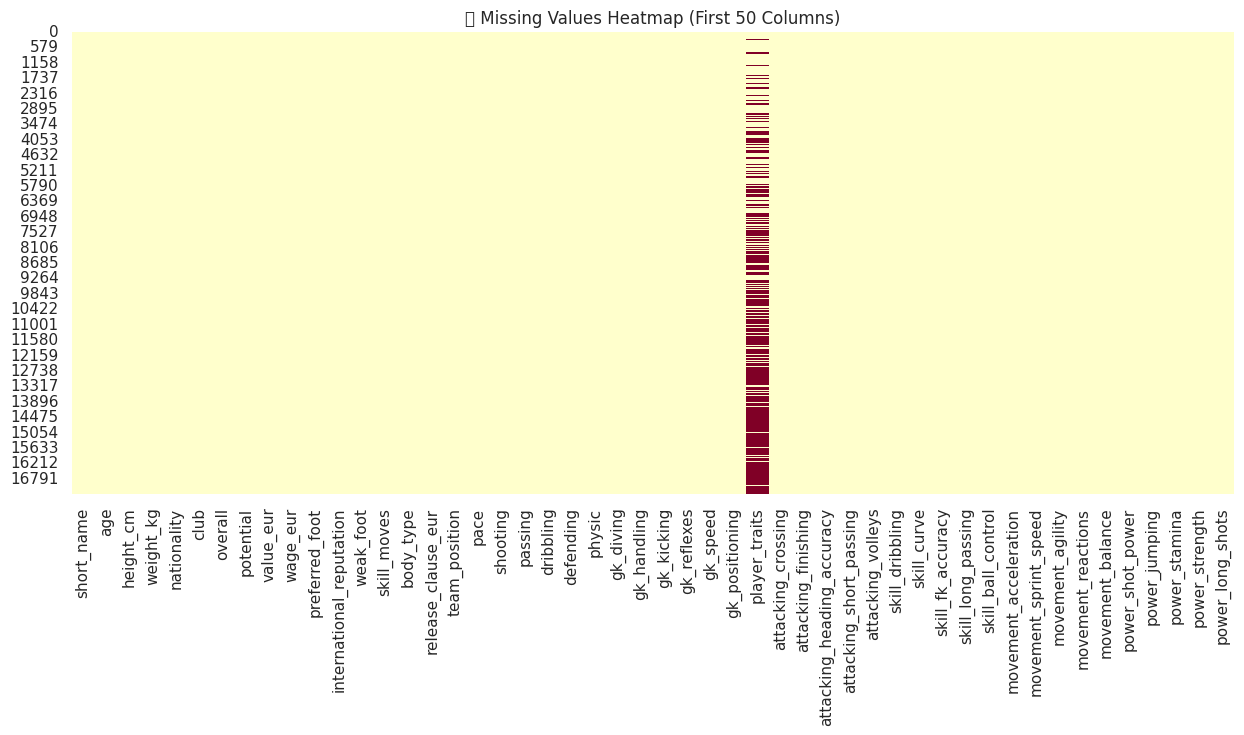

/tmp/ipython-input-126-1190831928.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df, x='MissingPercent', y='Feature', palette='viridis')
/tmp/ipython-input-126-1190831928.py:21: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


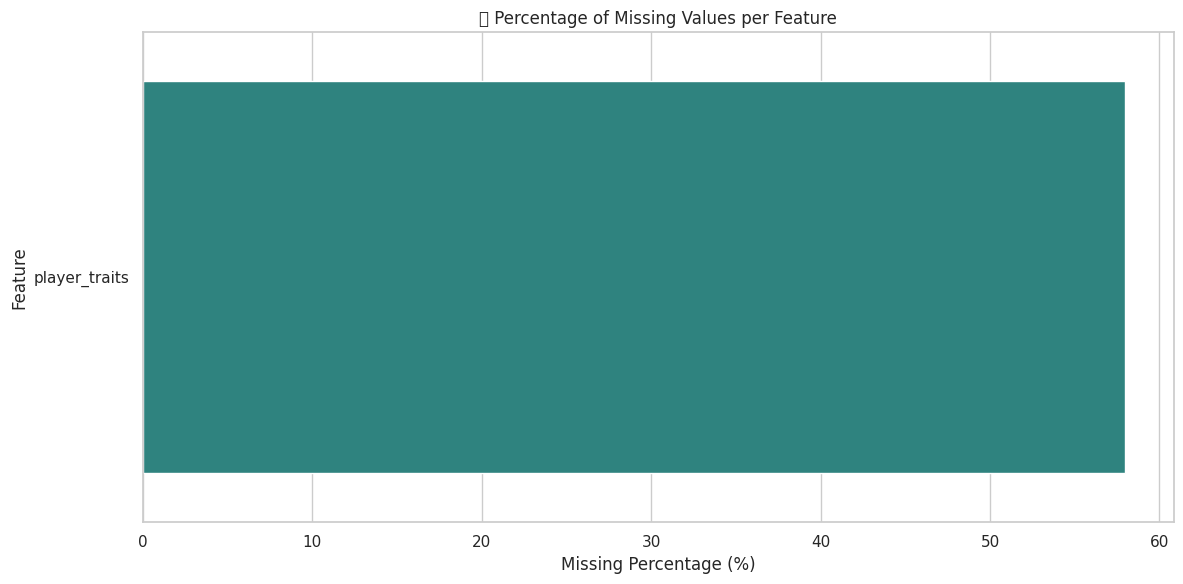

📌 Missing Value Summary:
 - Total features: 116
 - Features with missing values: 1
 - Total missing cells: 10058
 - Percentage of missing cells in dataset: 0.5%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Visualize missing values with a heatmap (first 50 columns to keep it readable)
plt.figure(figsize=(15, 6))
sns.heatmap(df.iloc[:, :50].isnull(), cbar=False, cmap='YlOrRd')
plt.title("🔍 Missing Values Heatmap (First 50 Columns)")
plt.show()

# 2️⃣ Calculate percentage of missing values per column
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100
missing_df = missing_percent[missing_percent > 0].reset_index()
missing_df.columns = ['Feature', 'MissingPercent']

# 📊 Bar plot of missing percentages
plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df, x='MissingPercent', y='Feature', palette='viridis')
plt.title("📉 Percentage of Missing Values per Feature")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 3️⃣ Print summary stats
total_missing_features = (missing_percent > 0).sum()
total_missing_cells = df.isnull().sum().sum()
total_features = df.shape[1]
total_rows = df.shape[0]

print("📌 Missing Value Summary:")
print(f" - Total features: {total_features}")
print(f" - Features with missing values: {total_missing_features}")
print(f" - Total missing cells: {total_missing_cells}")
print(f" - Percentage of missing cells in dataset: {round((total_missing_cells / (total_features * total_rows)) * 100, 2)}%")


# Handeling MIssing Droping PLayer traits

In [ ]:
# Drop 'player_traits' column due to high percentage of missing values
df.drop(columns=['player_traits'], inplace=True)
# df.columns.to_list()

## ✅ Step 3: Descriptive Statistics
Purpose: Understand the range, central tendency, and dispersion.

1.Use .describe() for numerical features

2.Count unique values in categorical features

3.Use .value_counts() for categorical distributions

In [ ]:
# Remove 'player_traits' if still in the list
categorical_cols = [col for col in categorical_cols if col in df.columns]

# 1. Numerical Summary Statistics
numerical_desc = df.describe().T
print("🔢 Numerical Feature Summary:")
display(numerical_desc)

# 2. Count unique values in categorical features
print("\n🔠 Unique Value Counts in Categorical Columns:")
for col in categorical_cols:
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} unique values")

# 3. Value distributions for categorical features (Top 5 values for each)
print("\n📊 Value Distributions in Categorical Columns:")
for col in categorical_cols:
    print(f"\n📌 {col} - Top 5 Most Frequent Values:")
    display(df[col].value_counts().head(5))


🔢 Numerical Feature Summary:


,count,mean,std,min,25%,50%,75%,max
age,17354.0,25.324133,4.653261,16.000000,22.000000,25.000000,29.000000,42.000000
height_cm,17354.0,181.401867,6.739291,156.000000,177.000000,181.000000,186.000000,205.000000
weight_kg,17354.0,75.311283,7.046480,50.000000,70.000000,75.000000,80.000000,110.000000
overall,17354.0,66.382390,6.959095,48.000000,62.000000,66.000000,71.000000,94.000000
potential,17354.0,71.620491,6.158721,49.000000,67.000000,71.000000,76.000000,95.000000
...,...,...,...,...,...,...,...,...
ST,17354.0,0.177365,0.381989,0.000000,0.000000,0.000000,0.000000,1.000000
tenure_years,17354.0,3.724617,2.420296,0.000000,2.000000,3.000000,5.000000,26.000000
log_value_eur,17354.0,13.685050,1.394509,9.210440,12.765691,13.493928,14.603968,18.474222
log_wage_eur,17354.0,8.268864,1.222346,6.908755,6.908755,8.006701,8.987322,13.244583



🔠 Unique Value Counts in Categorical Columns:
short_name: 17354 unique values
nationality: 161 unique values
club: 697 unique values
preferred_foot: 2 unique values
body_type: 3 unique values
team_position: 30 unique values
best_position: 10 unique values
primary_position: 15 unique values
role_group: 4 unique values

📊 Value Distributions in Categorical Columns:

📌 short_name - Top 5 Most Frequent Values:


,count
short_name,
Pan Ximing,1
L. Messi,1
Cristiano Ronaldo,1
Neymar Jr,1
J. Oblak,1



📌 nationality - Top 5 Most Frequent Values:


,count
nationality,
England,1542
Germany,1192
Spain,989
France,953
Argentina,814



📌 club - Top 5 Most Frequent Values:


,count
club,
Valencia CF,33
Borussia Mönchengladbach,33
RB Leipzig,33
SC Paderborn 07,33
Brighton & Hove Albion,33



📌 preferred_foot - Top 5 Most Frequent Values:


,count
preferred_foot,
Right,13241
Left,4113



📌 body_type - Top 5 Most Frequent Values:


,count
body_type,
Normal,10251
Lean,6156
Stocky,947



📌 team_position - Top 5 Most Frequent Values:


,count
team_position,
SUB,7407
RES,2772
LCB,634
GK,631
RCB,630



📌 best_position - Top 5 Most Frequent Values:


,count
best_position,
lcb,8165
ls,5001
lw,2017
lb,762
lf,441



📌 primary_position - Top 5 Most Frequent Values:


,count
primary_position,
CB,3003
ST,2429
CM,2073
GK,1925
CDM,1358



📌 role_group - Top 5 Most Frequent Values:


,count
role_group,
Midfielder,6535
Defender,5638
Attacker,3256
Goalkeeper,1925


## ✅ Step 4: Outlier Detection
Purpose: Identify extreme values that may distort analysis.

1.Use boxplots and z-score/IQR for key numerical columns

2.Flag or optionally cap/winsorize extreme values

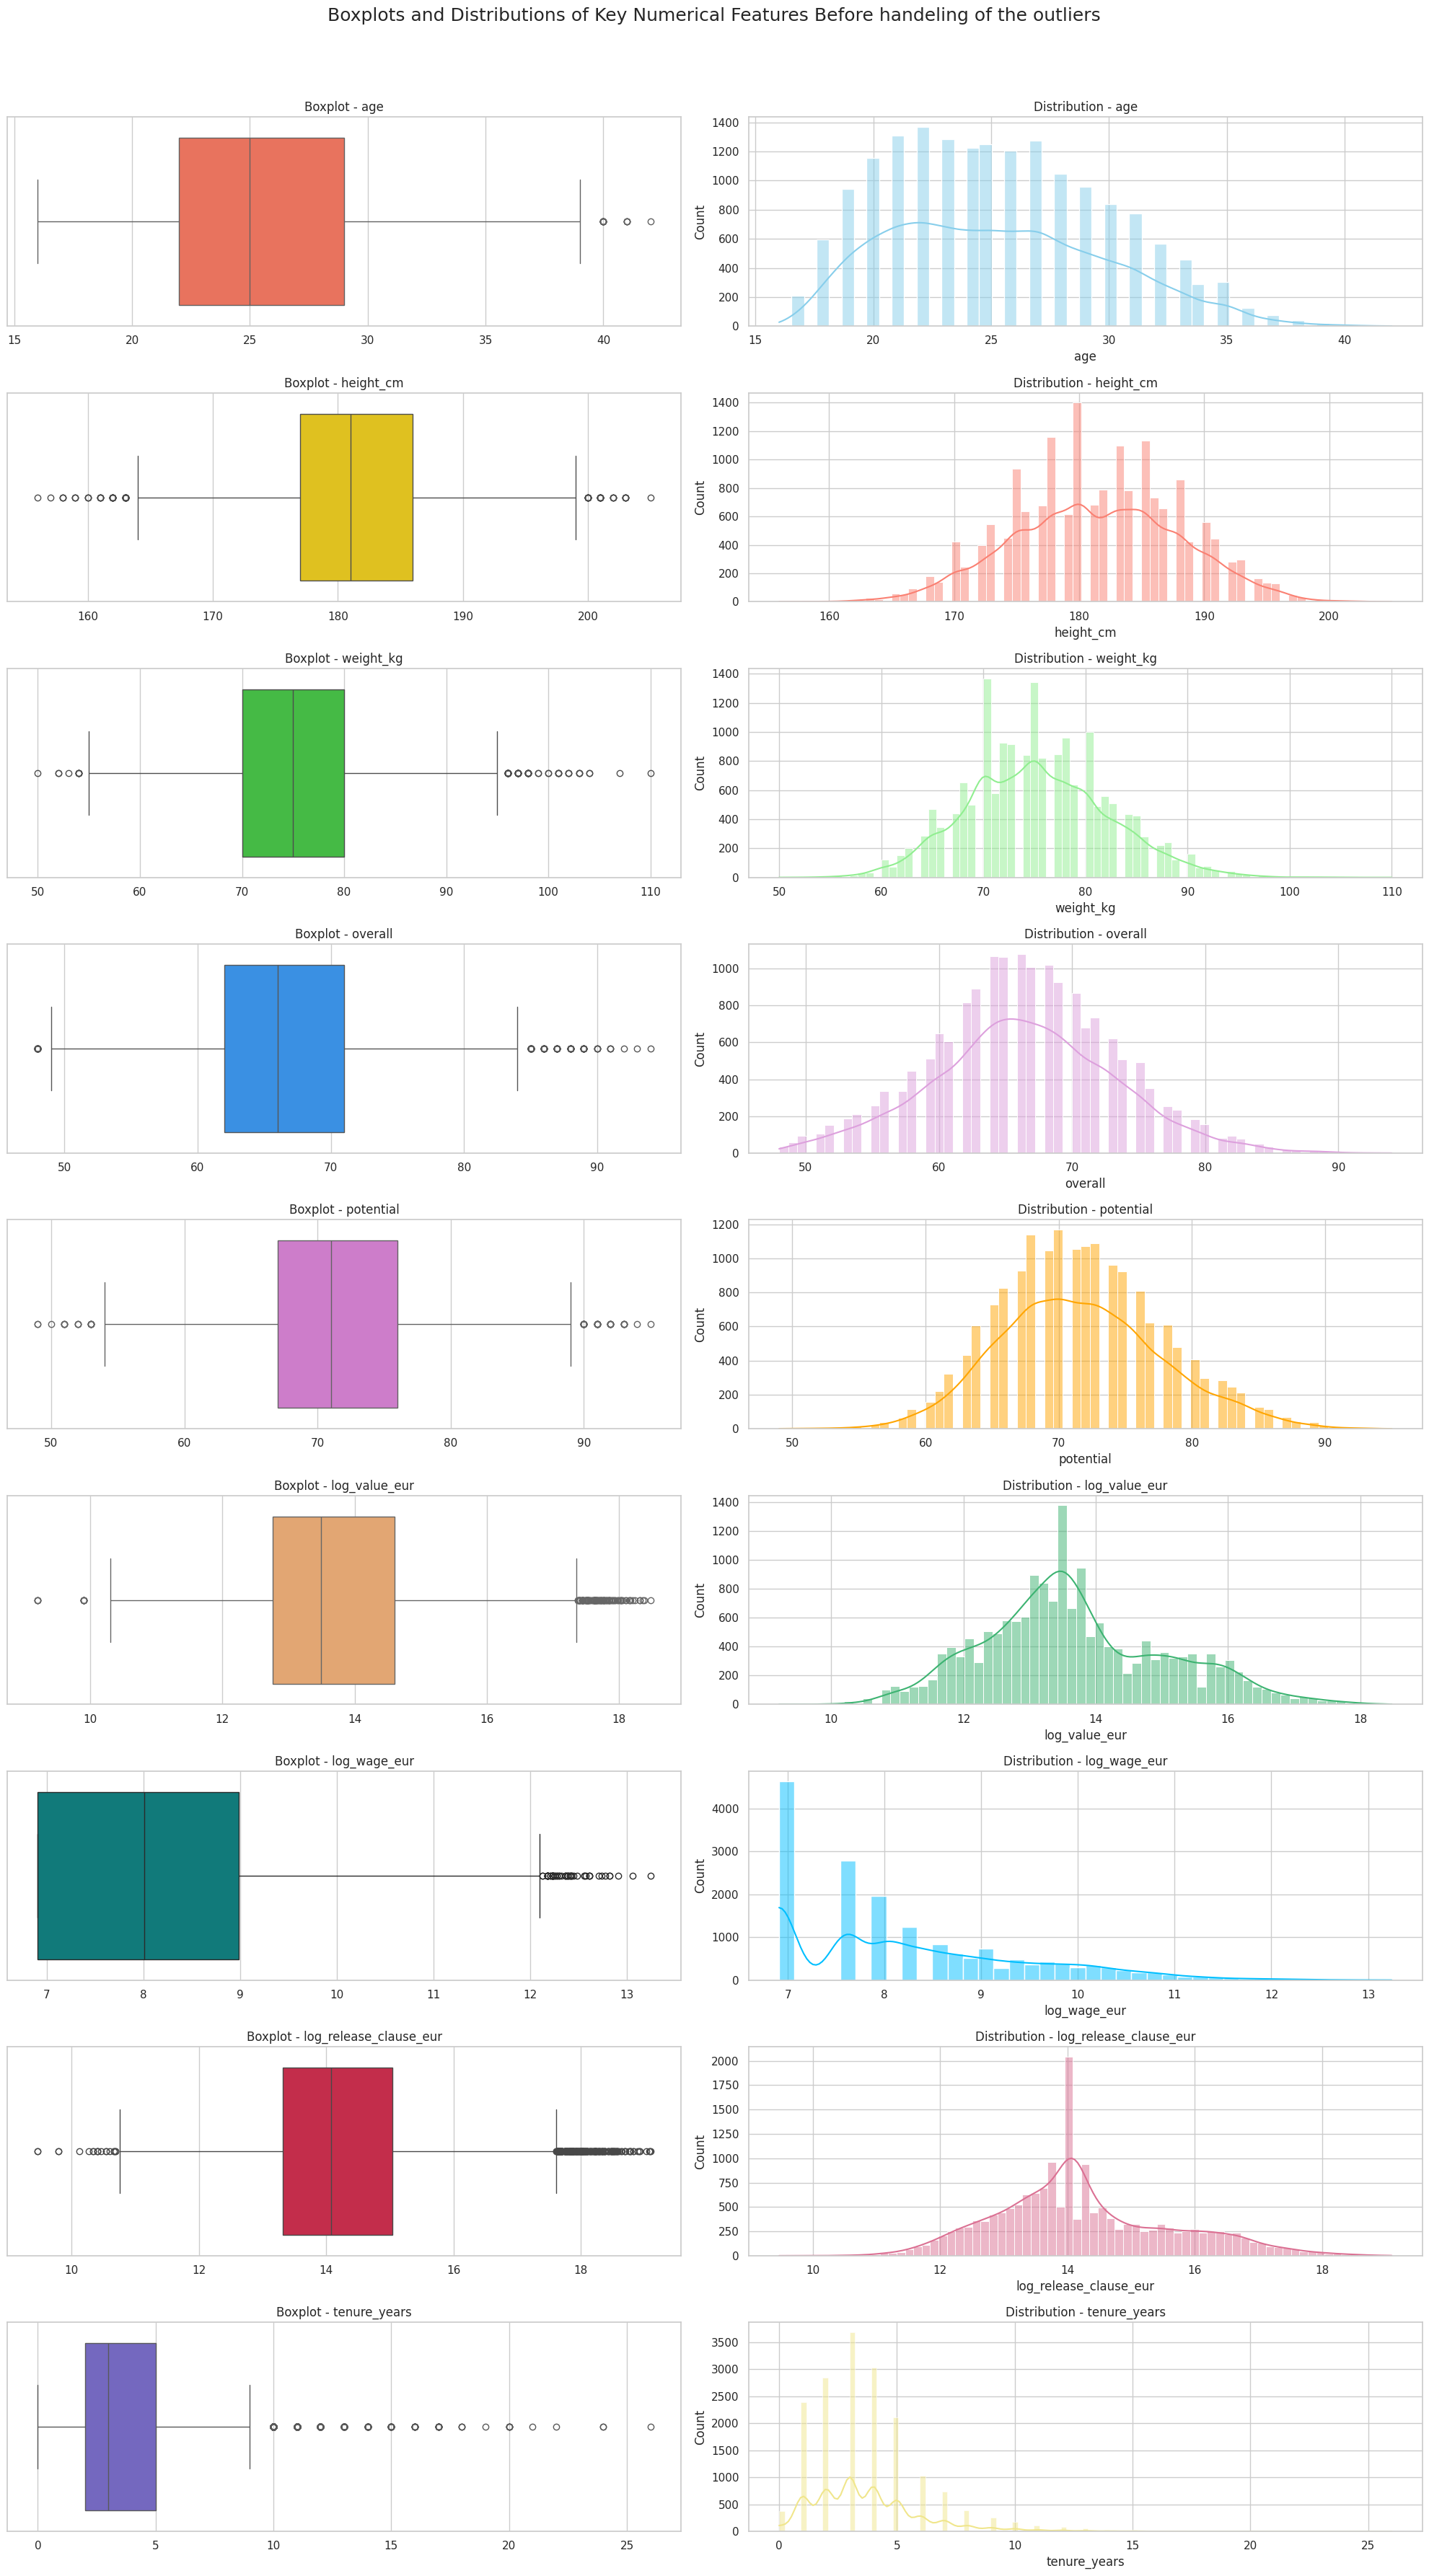

In [ ]:
# ✅ Part 1: Boxplots for Key Numerical Features
import matplotlib.pyplot as plt
import seaborn as sns

# Select key continuous features to visualize
key_features =[
    'age', 'height_cm', 'weight_kg',
    'overall', 'potential',
    'log_value_eur', 'log_wage_eur', 'log_release_clause_eur',
    'tenure_years'
]

# Different colors for variety
box_colors = ['tomato', 'gold', 'limegreen', 'dodgerblue', 'orchid', 'sandybrown', 'darkcyan', 'crimson', 'slateblue']
dist_colors = ['skyblue', 'salmon', 'lightgreen', 'plum', 'orange', 'mediumseagreen', 'deepskyblue', 'palevioletred', 'khaki']

# Set up the plot grid
plt.figure(figsize=(20, 35))
plt.suptitle('Boxplots and Distributions of Key Numerical Features Before handeling of the outliers', fontsize=18, y=1.02)

for i, col in enumerate(key_features):
    # Boxplot
    plt.subplot(len(key_features), 2, 2*i + 1)
    sns.boxplot(x=df[col], color=box_colors[i])
    plt.title(f'Boxplot - {col}', fontsize=12)
    plt.xlabel('')

    # KDE Distribution
    plt.subplot(len(key_features), 2, 2*i + 2)
    sns.histplot(df[col], kde=True, color=dist_colors[i])
    plt.title(f'Distribution - {col}', fontsize=12)
    plt.xlabel(col)

plt.tight_layout()
plt.show()


In [ ]:
# ✅ Part 1: Boxplots for Key Numerical Features
import matplotlib.pyplot as plt
import seaborn as sns

# Select key continuous features to visualize
Skill_Movement_Stats = [
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing',
    'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
    'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina',
    'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions',
    'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure',
    'defending_marking', 'defending_standing_tackle', 'defending_sliding_tackle'
]


# Different colors for variety
box_colors = ['tomato', 'gold', 'limegreen', 'dodgerblue', 'orchid', 'sandybrown', 'darkcyan', 'crimson', 'slateblue','tomato', 'gold', 'limegreen', 'dodgerblue', 'orchid', 'sandybrown', 'darkcyan', 'crimson', 'slateblue','tomato', 'gold', 'limegreen', 'dodgerblue', 'orchid', 'sandybrown', 'darkcyan', 'crimson', 'sandybrown', 'darkcyan', 'crimson']
dist_colors = ['skyblue', 'salmon', 'lightgreen', 'plum', 'orange', 'mediumseagreen', 'deepskyblue', 'palevioletred', 'khaki','skyblue', 'salmon', 'lightgreen', 'plum', 'orange', 'mediumseagreen', 'deepskyblue', 'palevioletred', 'khaki','skyblue', 'salmon', 'lightgreen', 'plum', 'orange', 'mediumseagreen', 'deepskyblue', 'palevioletred','mediumseagreen', 'deepskyblue', 'palevioletred']

# Set up the plot grid
plt.figure(figsize=(60, 105))
plt.suptitle('Boxplots and Distributions of Skill_Movement_Stats Before handeling of the outliers', fontsize=18, y=1.02)

for i, col in enumerate(Skill_Movement_Stats):
    # Boxplot
    plt.subplot(len(Skill_Movement_Stats), 2, 2*i + 1)
    sns.boxplot(x=df[col], color=box_colors[i])
    plt.title(f'Boxplot - {col}', fontsize=12)
    plt.xlabel('')

    # KDE Distribution
    plt.subplot(len(Skill_Movement_Stats), 2, 2*i + 2)
    sns.histplot(df[col], kde=True, color=dist_colors[i])
    plt.title(f'Distribution - {col}', fontsize=12)
    plt.xlabel(col)

plt.tight_layout()
plt.show()


In [ ]:
# ✅ Part 1: Boxplots for Key Numerical Features
import matplotlib.pyplot as plt
import seaborn as sns

# Select key continuous features to visualize
Positional_Effectiveness_Scores=[
'ls_score', 'st_score', 'rs_score', 'lw_score', 'lf_score', 'cf_score', 'rf_score', 'rw_score',
'lam_score', 'cam_score', 'ram_score', 'lm_score', 'lcm_score', 'cm_score', 'rcm_score', 'rm_score',
'lwb_score', 'ldm_score', 'cdm_score', 'rdm_score', 'rwb_score', 'lb_score', 'lcb_score',
'cb_score', 'rcb_score', 'rb_score']



# Different colors for variety
box_colors = ['tomato', 'gold', 'limegreen', 'dodgerblue', 'orchid', 'sandybrown', 'darkcyan', 'crimson', 'slateblue','tomato', 'gold', 'limegreen', 'dodgerblue', 'orchid', 'sandybrown', 'darkcyan', 'crimson', 'slateblue','tomato', 'gold', 'limegreen', 'dodgerblue', 'orchid', 'sandybrown', 'darkcyan', 'crimson']
dist_colors = ['skyblue', 'salmon', 'lightgreen', 'plum', 'orange', 'mediumseagreen', 'deepskyblue', 'palevioletred', 'khaki','skyblue', 'salmon', 'lightgreen', 'plum', 'orange', 'mediumseagreen', 'deepskyblue', 'palevioletred', 'khaki','skyblue', 'salmon', 'lightgreen', 'plum', 'orange', 'mediumseagreen', 'deepskyblue', 'palevioletred', 'khaki']

# Set up the plot grid
plt.figure(figsize=(60, 105))
plt.suptitle('Boxplots and Distributions of Skill_Movement_Stats Before handeling of the outliers', fontsize=18, y=1.02)

for i, col in enumerate(Positional_Effectiveness_Scores):
    # Boxplot
    plt.subplot(len(Positional_Effectiveness_Scores), 2, 2*i + 1)
    sns.boxplot(x=df[col], color=box_colors[i])
    plt.title(f'Boxplot - {col}', fontsize=12)
    plt.xlabel('')

    # KDE Distribution
    plt.subplot(len(Positional_Effectiveness_Scores), 2, 2*i + 2)
    sns.histplot(df[col], kde=True, color=dist_colors[i])
    plt.title(f'Distribution - {col}', fontsize=12)
    plt.xlabel(col)

plt.tight_layout()
plt.show()


In [ ]:
# ✅ Part 2: Detect Outliers Using IQR Method
# Define the key features
key_features =[
    'age', 'height_cm', 'weight_kg',
    'overall', 'potential',
    'log_value_eur', 'log_wage_eur', 'log_release_clause_eur',
    'tenure_years','ls_score', 'st_score', 'rs_score', 'lw_score', 'lf_score', 'cf_score', 'rf_score', 'rw_score',
'lam_score', 'cam_score', 'ram_score', 'lm_score', 'lcm_score', 'cm_score', 'rcm_score', 'rm_score',
'lwb_score', 'ldm_score', 'cdm_score', 'rdm_score', 'rwb_score', 'lb_score', 'lcb_score',
'cb_score', 'rcb_score', 'rb_score','attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing',
    'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
    'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina',
    'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions',
    'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure',
    'defending_marking', 'defending_standing_tackle', 'defending_sliding_tackle'
]

# IQR-based outlier detection for key features
def detect_outliers_iqr_selected(df, features):
    outlier_summary = {}

    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = len(outliers)

    # Convert to DataFrame
    outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
    outlier_df = outlier_df.sort_values(by='Outlier Count', ascending=False)
    return outlier_df

# Run the function on the cleaned DataFrame
outlier_key_features = detect_outliers_iqr_selected(df, key_features)

# Display results
outlier_key_features



,Outlier Count
skill_ball_control,1940
skill_dribbling,1919
attacking_short_passing,1632
lw_score,1307
rw_score,1307
...,...
mentality_positioning,0
mentality_interceptions,0
defending_marking,0
defending_standing_tackle,0


In [ ]:
print(df['best_position'].unique())



['lcb' 'lw' 'ls' 'lb' 'lwb' 'lam' 'lf' 'ldm' 'lm' 'lcm']


In [ ]:
outlier_key_features.columns.to_list()

['Outlier Count']

# To handle the left over outliers

In [ ]:
import numpy as np
import pandas as pd

# List of features to aggressively cap
aggressive_features =[
    'skill_ball_control', 'skill_dribbling', 'attacking_short_passing',
    'lw_score', 'rw_score', 'ram_score', 'lam_score', 'cam_score', 'rm_score', 'lm_score',
    'attacking_heading_accuracy', 'cf_score', 'rf_score', 'lf_score',
    'power_stamina', 'rwb_score', 'lwb_score', 'rs_score', 'st_score', 'ls_score',
    'ldm_score', 'rdm_score', 'cdm_score', 'rcm_score', 'cm_score', 'lcm_score',
    'rb_score', 'lb_score', 'rcb_score', 'lcb_score', 'cb_score',
    'tenure_years', 'log_release_clause_eur', 'log_value_eur', 'log_wage_eur',
    'movement_sprint_speed', 'power_jumping', 'movement_acceleration', 'movement_agility',
    'movement_balance', 'movement_reactions', 'power_strength', 'mentality_composure',
    'mentality_vision', 'height_cm', 'weight_kg', 'overall', 'potential', 'age'
]
# Function for 1.0×IQR aggressive capping
def aggressive_cap_and_check(df, features, iqr_factor=1.0):
    outlier_summary = {}
    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - iqr_factor * IQR
        upper = Q3 + iqr_factor * IQR

        # Capping
        df[col] = np.clip(df[col], lower, upper)

        # Recheck for remaining outliers
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_summary[col] = len(outliers)

    # Display results
    print("✅ Aggressive Capping Done (1.0×IQR)")
    print("🔍 Remaining Outliers After Capping:")
    print(pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count']))

# Call the function
aggressive_cap_and_check(df, aggressive_features)

✅ Aggressive Capping Done (1.0×IQR)
🔍 Remaining Outliers After Capping:
                            Outlier Count
skill_ball_control                      0
skill_dribbling                         0
attacking_short_passing                 0
lw_score                                0
rw_score                                0
ram_score                               0
lam_score                               0
cam_score                               0
rm_score                                0
lm_score                                0
attacking_heading_accuracy              0
cf_score                                0
rf_score                                0
lf_score                                0
power_stamina                           0
rwb_score                               0
lwb_score                               0
rs_score                                0
st_score                                0
ls_score                                0
ldm_score                               0
rdm_

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## ✅ Step 5: Feature Correlation & Redundancy
Purpose: Discover redundant or highly correlated features.

1.Generate a heatmap of Pearson correlations

2.Use .corr() and optional VIF if preparing for linear modeling

3.Consider PCA or feature pruning based on findings

# Group wise Heatmaps And Corelation

#1.🟩 Basic Demographics

📊 Correlation Matrix:
               age  height_cm  weight_kg
age        1.00000   0.080460   0.235500
height_cm  0.08046   1.000000   0.771974
weight_kg  0.23550   0.771974   1.000000

📏 Covariance Matrix:
                 age  height_cm  weight_kg
age        21.249705   2.431457   7.414105
height_cm   2.431457  42.975206  34.562380
weight_kg   7.414105  34.562380  46.642768


/tmp/ipython-input-137-2617342371.py:34: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


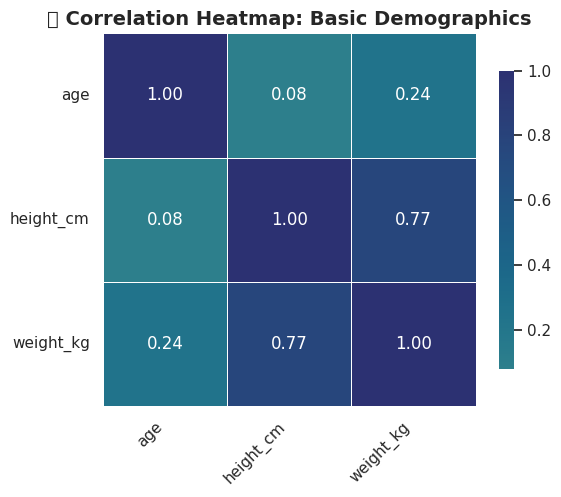

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group: Basic Demographics
basic_demo_features = ['age', 'height_cm', 'weight_kg']
demo_df = df[basic_demo_features].dropna()

# 🔢 1. Correlation Matrix
correlation_matrix = demo_df.corr()
print("📊 Correlation Matrix:")
print(correlation_matrix)

# 🔣 2. Covariance Matrix
covariance_matrix = demo_df.cov()
print("\n📏 Covariance Matrix:")
print(covariance_matrix)

# 📌 3. Heatmap of Correlation
plt.figure(figsize=(6, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="crest",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("🟩 Correlation Heatmap: Basic Demographics", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#2.🟦 General Player Quality

📊 Correlation Matrix:
                         overall  potential  log_value_eur  log_wage_eur  \
overall                 1.000000   0.640275       0.939486      0.800224   
potential               0.640275   1.000000       0.773556      0.558635   
log_value_eur           0.939486   0.773556       1.000000      0.802918   
log_wage_eur            0.800224   0.558635       0.802918      1.000000   
log_release_clause_eur  0.892204   0.788161       0.967031      0.776992   

                        log_release_clause_eur  
overall                               0.892204  
potential                             0.788161  
log_value_eur                         0.967031  
log_wage_eur                          0.776992  
log_release_clause_eur                1.000000  

📏 Covariance Matrix:
                          overall  potential  log_value_eur  log_wage_eur  \
overall                 43.884416  25.480265       8.376223      6.317836   
potential               25.480265  36.088154       

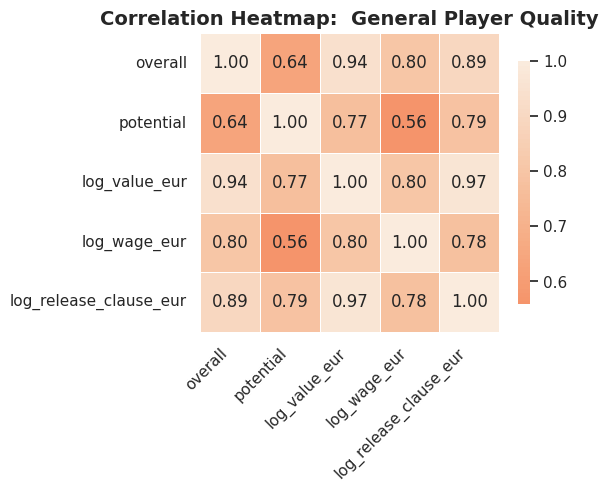

In [ ]:
General_Player_Quality =['overall', 'potential', 'log_value_eur', 'log_wage_eur', 'log_release_clause_eur']
demo_df = df[General_Player_Quality].dropna()
# 🔢 1. Correlation Matrix
correlation_matrix = demo_df.corr()
print("📊 Correlation Matrix:")
print(correlation_matrix)
# 🔣 2. Covariance Matrix
covariance_matrix = demo_df.cov()
print("\n📏 Covariance Matrix:")
print(covariance_matrix)
# 📌 3. Heatmap of Correlation
plt.figure(figsize=(6, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="rocket",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap:  General Player Quality", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 3.🟧 Skill & Movement Stats

📊 Correlation Matrix:
                            attacking_crossing  attacking_finishing  \
attacking_crossing                    1.000000             0.670571   
attacking_finishing                   0.670571             1.000000   
attacking_heading_accuracy            0.408278             0.432589   
attacking_short_passing               0.788737             0.636613   
attacking_volleys                     0.696630             0.891718   
skill_dribbling                       0.843060             0.825184   
skill_curve                           0.838667             0.772352   
skill_fk_accuracy                     0.763316             0.709648   
skill_long_passing                    0.752538             0.527985   
skill_ball_control                    0.828859             0.793129   
movement_acceleration                 0.664473             0.598759   
movement_sprint_speed                 0.639702             0.583091   
movement_agility                      0.696874         

/tmp/ipython-input-139-3252155589.py:42: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


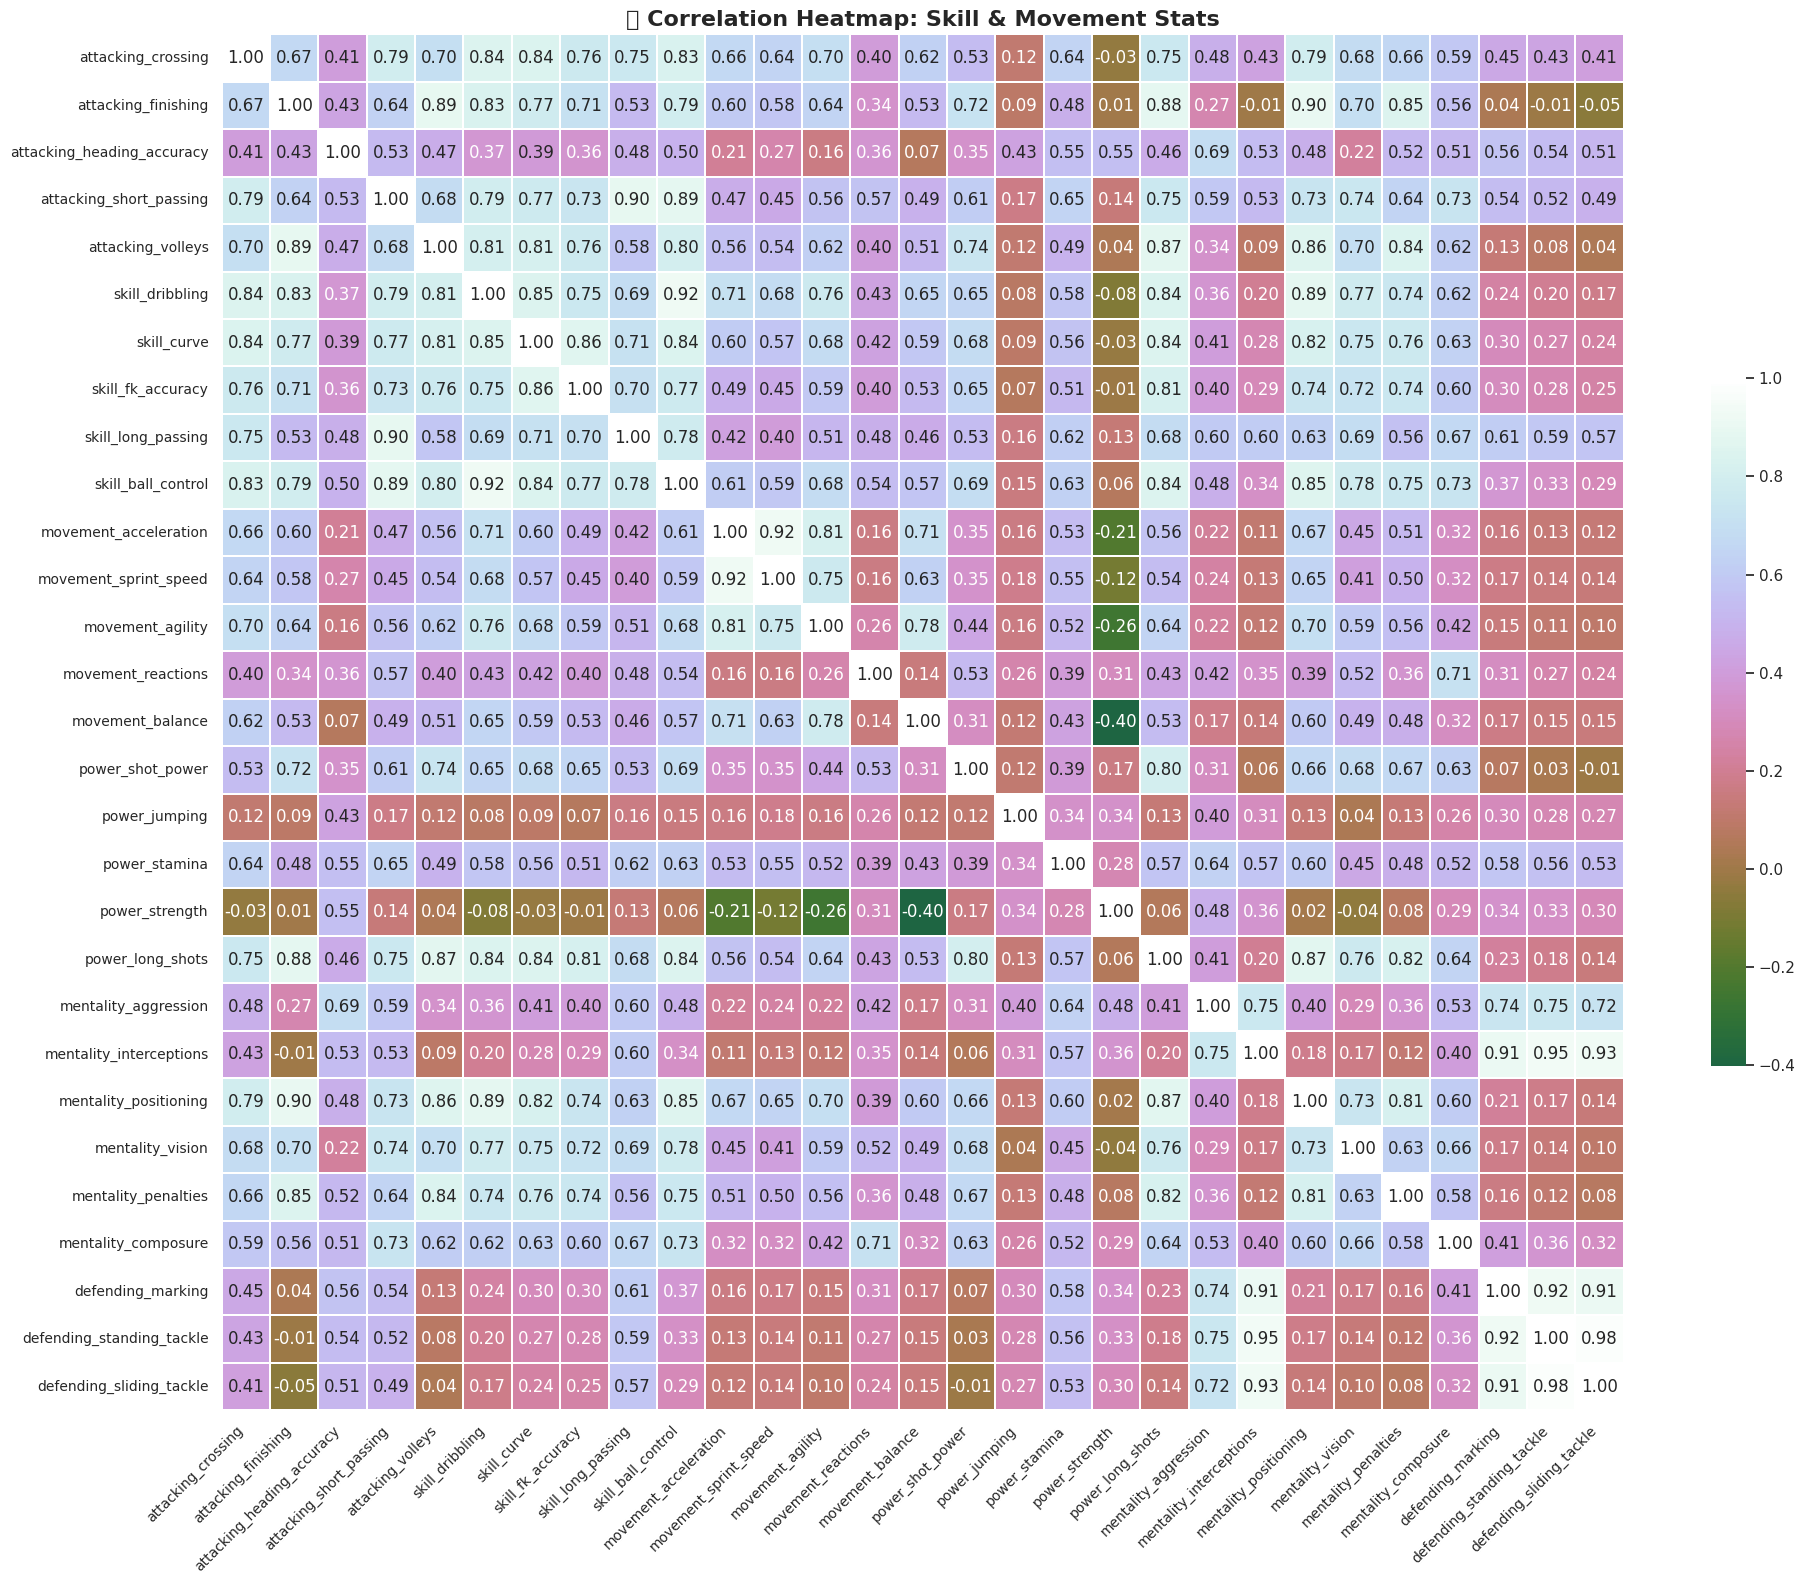

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation
Skill_Movement_Stats = [
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing',
    'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
    'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina',
    'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions',
    'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure',
    'defending_marking', 'defending_standing_tackle', 'defending_sliding_tackle'
]

demo_df = df[Skill_Movement_Stats].dropna()

# 2. Correlation Matrix
correlation_matrix = demo_df.corr()
print("📊 Correlation Matrix:")
print(correlation_matrix)

# 3. Covariance Matrix
covariance_matrix = demo_df.cov()
print("\n📏 Covariance Matrix:")
print(covariance_matrix)

# 4. Heatmap of Correlation
plt.figure(figsize=(20, 16))  # Adjusted for 28 features
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="cubehelix",
    center=0,
    square=False,
    linewidths=0.3,
    cbar_kws={"shrink": 0.5}
)
plt.title("🟦 Correlation Heatmap: Skill & Movement Stats", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


#4.Goalkeeping_Attributes

📊 Correlation Matrix:
                gk_diving  gk_handling  gk_kicking  gk_reflexes  gk_speed  \
gk_diving        1.000000     0.997641    0.995752     0.998649  0.967790   
gk_handling      0.997641     1.000000    0.995947     0.997323  0.965699   
gk_kicking       0.995752     0.995947    1.000000     0.995495  0.964946   
gk_reflexes      0.998649     0.997323    0.995495     1.000000  0.968054   
gk_speed         0.967790     0.965699    0.964946     0.968054  1.000000   
gk_positioning   0.997360     0.997746    0.995288     0.997360  0.967294   

                gk_positioning  
gk_diving             0.997360  
gk_handling           0.997746  
gk_kicking            0.995288  
gk_reflexes           0.997360  
gk_speed              0.967294  
gk_positioning        1.000000  

📏 Covariance Matrix:
                 gk_diving  gk_handling  gk_kicking  gk_reflexes    gk_speed  \
gk_diving       430.048417   414.300936  405.044412   436.345358  248.586699   
gk_handling     414.30093

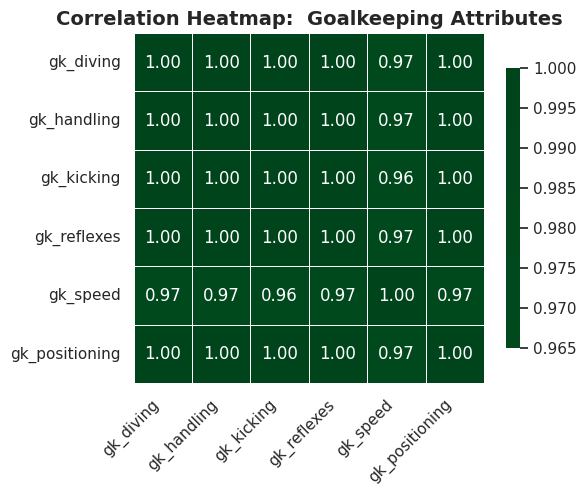

In [ ]:
Goalkeeping_Attributes =['gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning']
demo_df = df[Goalkeeping_Attributes].dropna()
# 🔢 1. Correlation Matrix
correlation_matrix = demo_df.corr()
print("📊 Correlation Matrix:")
print(correlation_matrix)
# 🔣 2. Covariance Matrix
covariance_matrix = demo_df.cov()
print("\n📏 Covariance Matrix:")
print(covariance_matrix)
# 📌 3. Heatmap of Correlation
plt.figure(figsize=(6, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap:  Goalkeeping Attributes", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#5.🟪 FIFA Simplified Metrics  Contract & Work Rate  Footedness & Reputation Together


📊 Correlation Matrix:
                              pace  shooting   passing  dribbling  defending  \
pace                      1.000000  0.348799  0.288183   0.547555  -0.299539   
shooting                  0.348799  1.000000  0.657333   0.767725  -0.401083   
passing                   0.288183  0.657333  1.000000   0.830730   0.156045   
dribbling                 0.547555  0.767725  0.830730   1.000000  -0.163384   
defending                -0.299539 -0.401083  0.156045  -0.163384   1.000000   
physic                   -0.197089  0.004846  0.132869  -0.043473   0.555323   
tenure_years              0.015272  0.062369  0.160911   0.121778   0.148832   
international_reputation  0.005238  0.263841  0.341917   0.285614   0.129878   
weak_foot                 0.124705  0.277913  0.248885   0.268300  -0.117486   
skill_moves               0.301012  0.461354  0.463381   0.527078  -0.217265   

                            physic  tenure_years  international_reputation  \
pace               

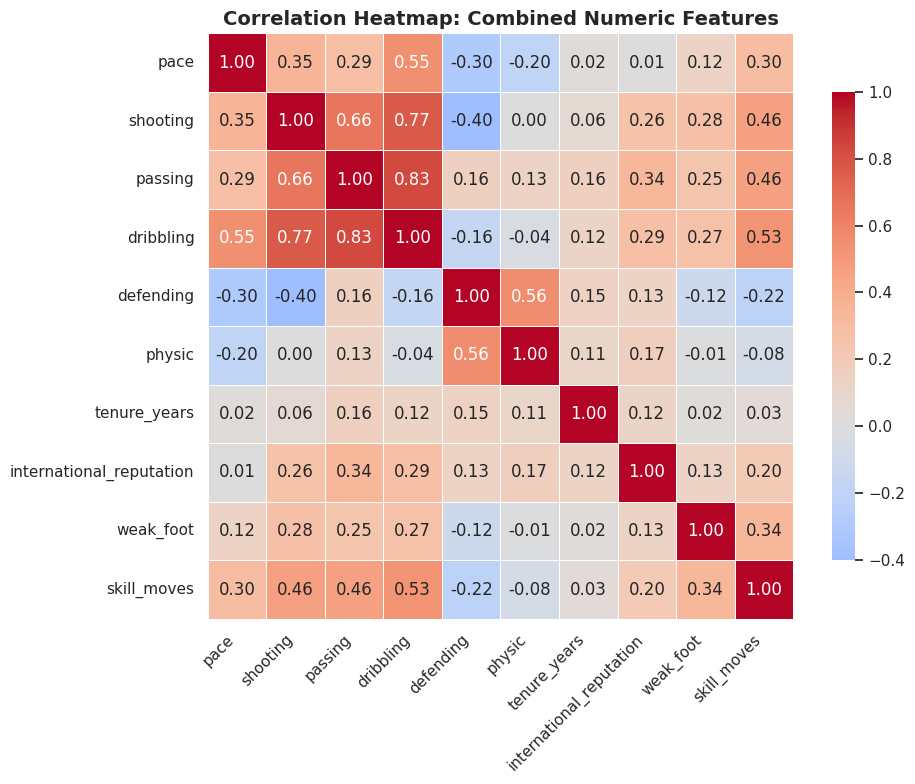

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Step 1: Keep only numeric-compatible features
Combined_Features = [
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'tenure_years', 'international_reputation', 'weak_foot', 'skill_moves'
]

# ✅ Step 2: Create cleaned numeric DataFrame
demo_df = df[Combined_Features].copy()
demo_df = demo_df.dropna()  # Ensure all values are valid

# 🔢 Step 3: Correlation Matrix
correlation_matrix = demo_df.corr()
print("📊 Correlation Matrix:")
print(correlation_matrix)

# 🔣 Step 4: Covariance Matrix
covariance_matrix = demo_df.cov()
print("\n📏 Covariance Matrix:")
print(covariance_matrix)

# 📌 Step 5: Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",  # 🌈 Better visual contrast
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap: Combined Numeric Features", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 🟨 6 Positional Effectiveness Scores

📊 Correlation Matrix:
           ls_score  st_score  rs_score  lw_score  lf_score  cf_score  \
ls_score   1.000000  1.000000  1.000000  0.927450  0.968872  0.968872   
st_score   1.000000  1.000000  1.000000  0.927450  0.968872  0.968872   
rs_score   1.000000  1.000000  1.000000  0.927450  0.968872  0.968872   
lw_score   0.927450  0.927450  0.927450  1.000000  0.983296  0.983296   
lf_score   0.968872  0.968872  0.968872  0.983296  1.000000  1.000000   
cf_score   0.968872  0.968872  0.968872  0.983296  1.000000  1.000000   
rf_score   0.968872  0.968872  0.968872  0.983296  1.000000  1.000000   
rw_score   0.927450  0.927450  0.927450  1.000000  0.983296  0.983296   
lam_score  0.929498  0.929498  0.929498  0.980902  0.984567  0.984567   
cam_score  0.929498  0.929498  0.929498  0.980902  0.984567  0.984567   
ram_score  0.929498  0.929498  0.929498  0.980902  0.984567  0.984567   
lm_score   0.896220  0.896220  0.896220  0.984962  0.962403  0.962403   
lcm_score  0.769898  0.769898

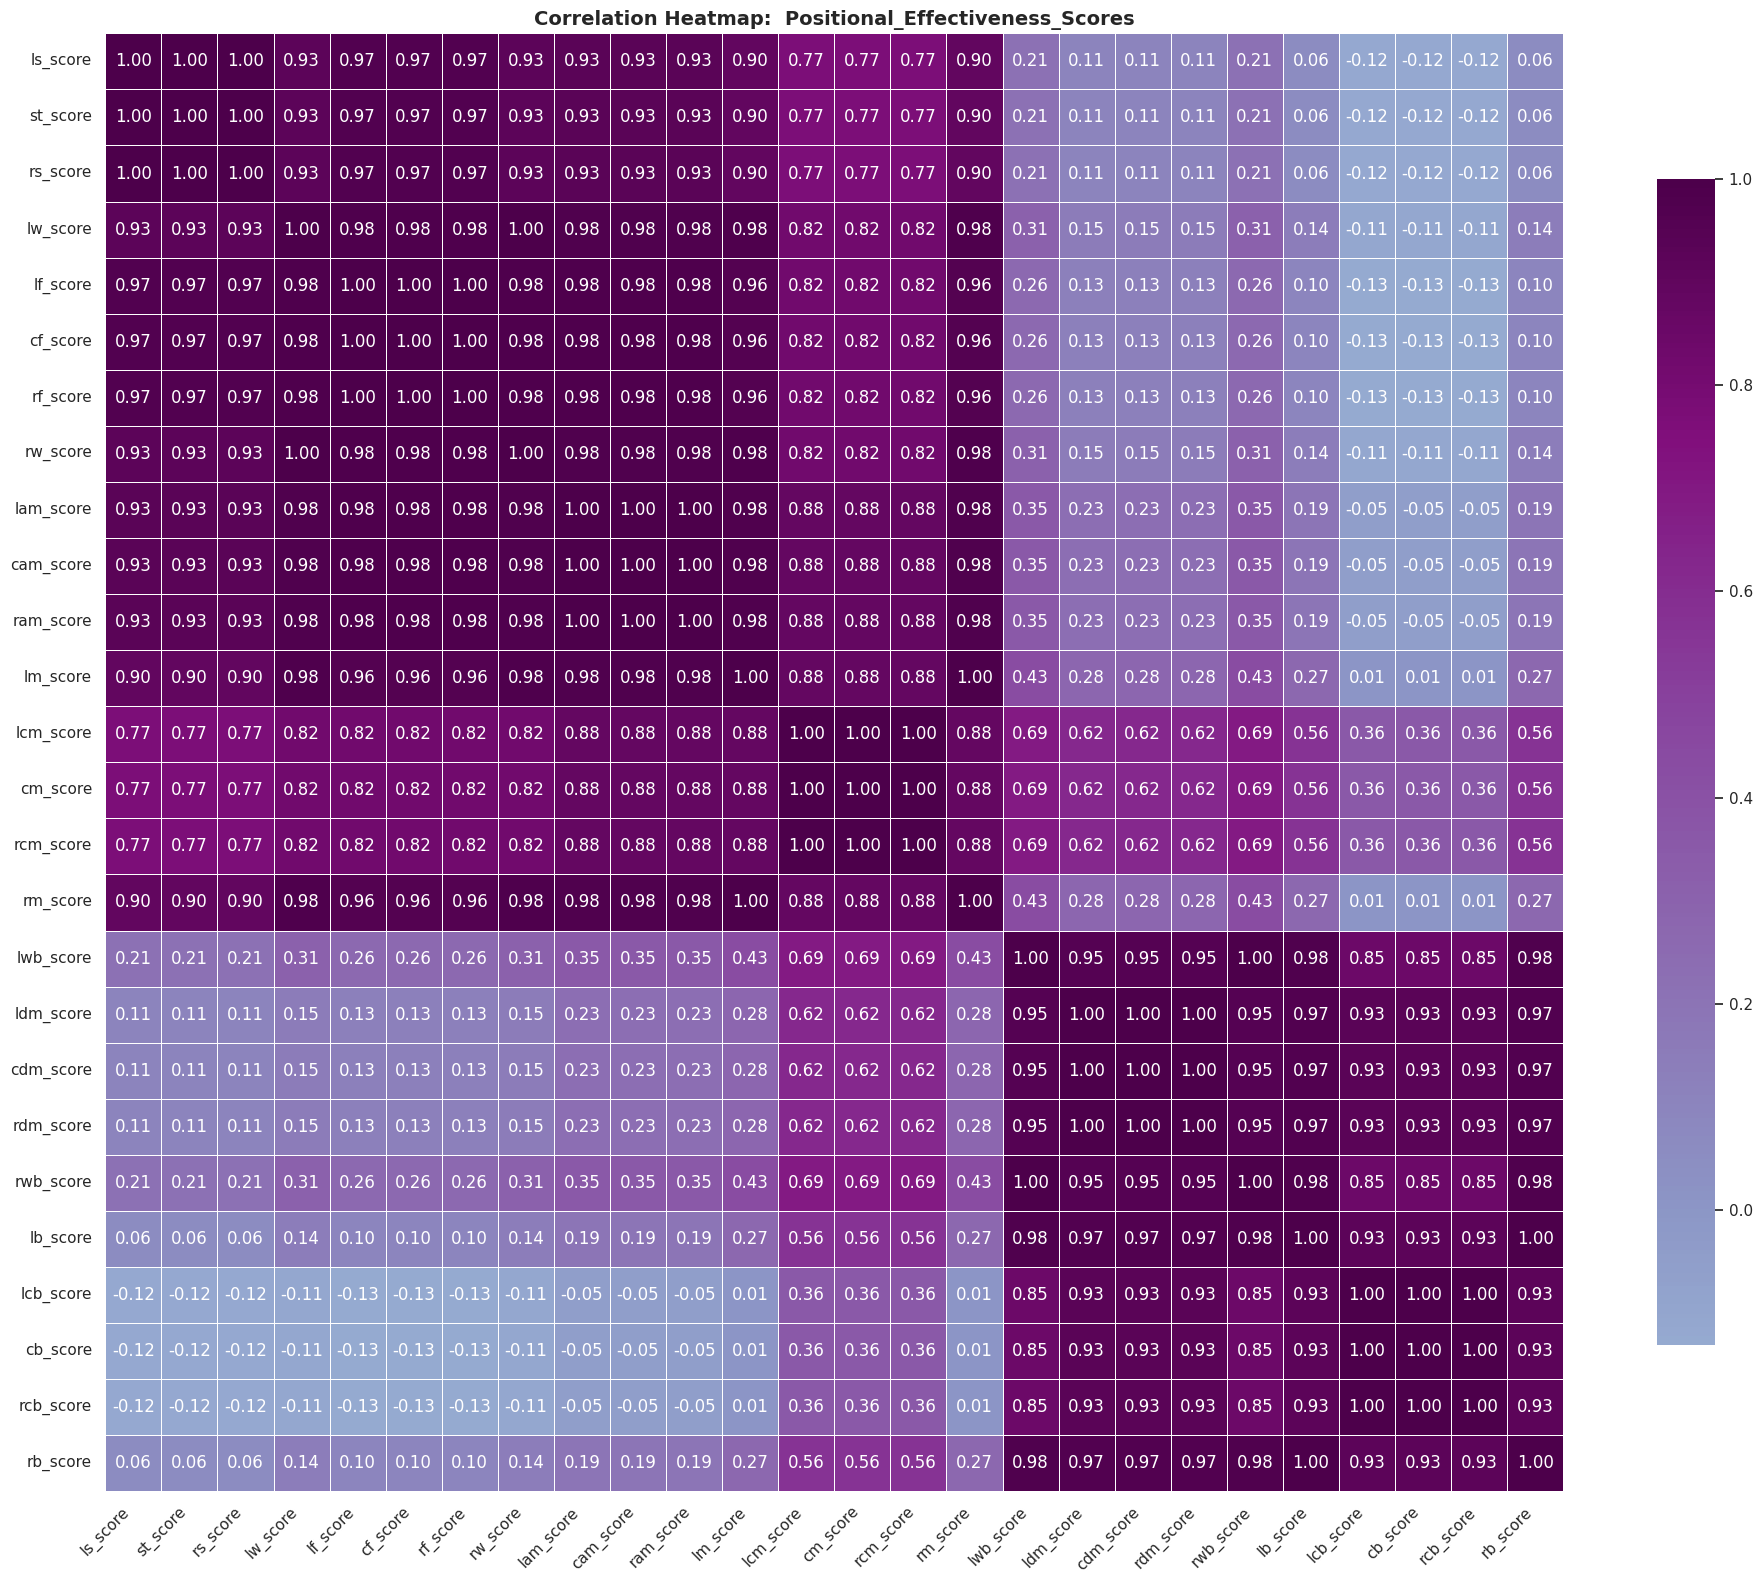

In [ ]:
Positional_Effectiveness_Scores=[
'ls_score', 'st_score', 'rs_score', 'lw_score', 'lf_score', 'cf_score', 'rf_score', 'rw_score',
'lam_score', 'cam_score', 'ram_score', 'lm_score', 'lcm_score', 'cm_score', 'rcm_score', 'rm_score',
'lwb_score', 'ldm_score', 'cdm_score', 'rdm_score', 'rwb_score', 'lb_score', 'lcb_score',
'cb_score', 'rcb_score', 'rb_score']

demo_df = df[Positional_Effectiveness_Scores].dropna()
# 🔢 1. Correlation Matrix
correlation_matrix = demo_df.corr()
print("📊 Correlation Matrix:")
print(correlation_matrix)
# 🔣 2. Covariance Matrix
covariance_matrix = demo_df.cov()
print("\n📏 Covariance Matrix:")
print(covariance_matrix)
# 📌 3. Heatmap of Correlation
plt.figure(figsize=(20, 16))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="BuPu",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap:  Positional_Effectiveness_Scores", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#🧠 Key Recommendations Summary
| Group                  | Recommendation                         |
| ---------------------- | -------------------------------------- |
| Basic Demographics     | Keep all, low correlation, no changes. |
| General Player Quality | Drop raw financials; keep logs.        |
| Skill & Movement       | Consider PCA or skill grouping.        |
| Goalkeeping Attributes | Strong PCA candidate or single score.  |
| Combined Group         | Review categorical impacts.            |
| Positional Scores      | PCA or aggregate position categories.  |


##✅ Step 6: Distribution Analysis
Purpose: Understand shape and skewness of numerical features.

1.Plot histograms (univariate)

2.Plot KDE curves for smooth density

3.Identify features needing normalization/log-transform

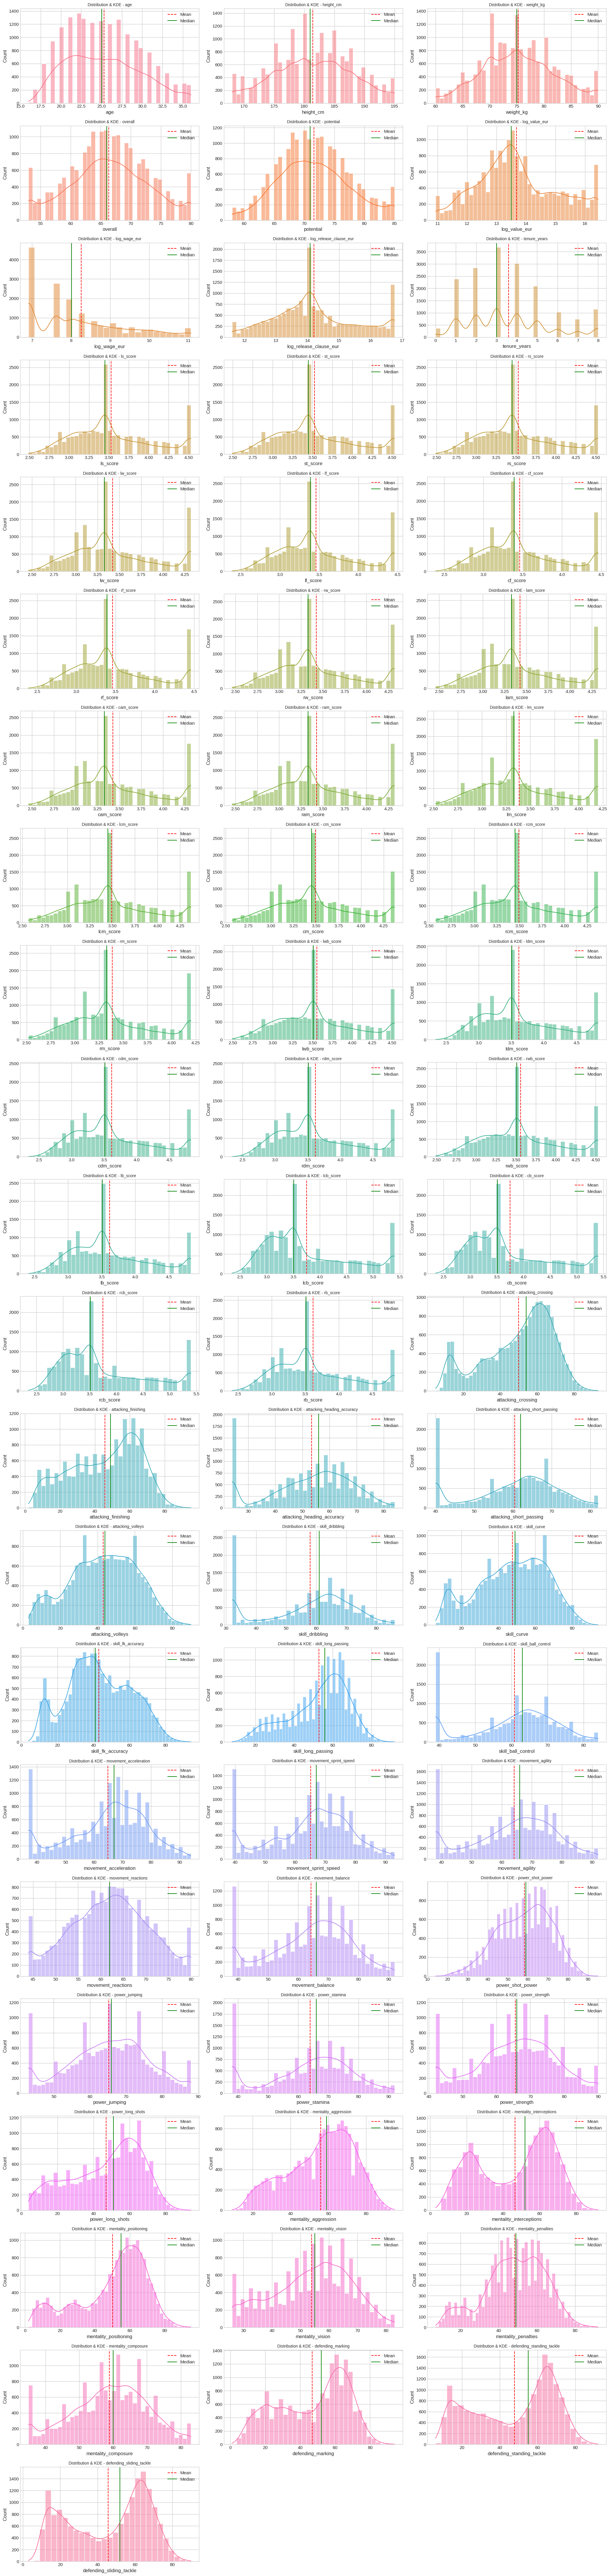

📦 Skewness Summary:
age                           : 0.32
height_cm                     : -0.01
weight_kg                     : 0.11
overall                       : 0.0
potential                     : 0.19
log_value_eur                 : 0.29
log_wage_eur                  : 0.63
log_release_clause_eur        : 0.31
tenure_years                  : 0.53
ls_score                      : 0.51
st_score                      : 0.51
rs_score                      : 0.51
lw_score                      : 0.51
lf_score                      : 0.58
cf_score                      : 0.58
rf_score                      : 0.58
rw_score                      : 0.51
lam_score                     : 0.49
cam_score                     : 0.49
ram_score                     : 0.49
lm_score                      : 0.44
lcm_score                     : 0.37
cm_score                      : 0.37
rcm_score                     : 0.37
rm_score                      : 0.44
lwb_score                     : 0.41
ldm_score         

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# 🔢 Key numerical features
key_features = [
    'age', 'height_cm', 'weight_kg',
    'overall', 'potential',
    'log_value_eur', 'log_wage_eur', 'log_release_clause_eur',
    'tenure_years', 'ls_score', 'st_score', 'rs_score', 'lw_score', 'lf_score', 'cf_score', 'rf_score', 'rw_score',
    'lam_score', 'cam_score', 'ram_score', 'lm_score', 'lcm_score', 'cm_score', 'rcm_score', 'rm_score',
    'lwb_score', 'ldm_score', 'cdm_score', 'rdm_score', 'rwb_score', 'lb_score', 'lcb_score',
    'cb_score', 'rcb_score', 'rb_score', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing',
    'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
    'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina',
    'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions',
    'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure',
    'defending_marking', 'defending_standing_tackle', 'defending_sliding_tackle'
]

# 📦 Skewness storage
skewness_dict = {}

# 📊 Auto grid layout based on feature count
n_cols = 3
n_rows = int(np.ceil(len(key_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*7, n_rows*4))
axes = axes.flatten()

# 🔄 Loop through features
for i, col in enumerate(key_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette("husl", len(key_features))[i])
    axes[i].set_title(f'Distribution & KDE - {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='-', label='Median')
    axes[i].legend()

    skew_val = df[col].skew()
    skewness_dict[col] = round(skew_val, 2)

# 🔁 Clear unused axes (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 📌 Skewness summary
print("📦 Skewness Summary:")
for k, v in skewness_dict.items():
    print(f"{k:<30}: {v}")

# ⚠️ Highly skewed
print("\n⚠️ Features with |skew| > 1 (Highly Skewed):")
for k, v in skewness_dict.items():
    if abs(v) > 1:
        print(f"➡️ {k:<30}: {v}")


# No skewness in The given numerical values

## ✅ Step 7: Final Data Checkpoint
Purpose: Confirm dataset is modeling-ready.

1.Re-check for duplicates and missing values

2.Validate types and ranges

3.Document key findings for modeling phase

#🎯 Purpose:
Ensure the dataset is free of critical issues before moving to the modeling phase like PCA, clustering, or classification.



#🔍 1. Check for Missing Values & Duplicates

In [ ]:
print("🔎 Checking for Missing Values...")
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
if missing_cols.empty:
    print("✅ No missing values found.")
else:
    print("⚠️ Columns with missing values:")
    print(missing_cols)

print("\n🔎 Checking for Duplicate Rows...")
duplicate_count = df.duplicated().sum()
print(f"🧾 Duplicate rows: {duplicate_count}")


🔎 Checking for Missing Values...
✅ No missing values found.

🔎 Checking for Duplicate Rows...
🧾 Duplicate rows: 0


#🧪 2. Validate Data Types & Ranges

In [ ]:
print("\n🔎 Validating Data Types...")
print(df.dtypes.value_counts())

print("\n🔍 Summary Statistics:")
display(df.describe())

# Example range checks for key columns (customize as needed)
print("\n🧮 Range Check - Sample Columns:")
print(f"Age range: {df['age'].min()} - {df['age'].max()}")
print(f"Overall rating range: {df['overall'].min()} - {df['overall'].max()}")
print(f"Potential range: {df['potential'].min()} - {df['potential'].max()}")



🔎 Validating Data Types...
int64      62
float64    44
object      9
Name: count, dtype: int64

🔍 Summary Statistics:


,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,skill_moves,...,LWB,RB,RM,RW,RWB,ST,tenure_years,log_value_eur,log_wage_eur,log_release_clause_eur
count,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,1.735400e+04,17354.000000,17354.000000,17354.000000,17354.000000,...,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000,17354.000000
mean,25.307307,181.414198,75.258211,66.359571,71.590700,2.566709e+06,9758.672352,1.107295,2.949061,2.374323,...,0.017287,0.109542,0.127406,0.054051,0.016423,0.177365,3.594733,13.670471,8.257505,14.202525
std,4.609740,6.555548,6.829551,6.624531,6.007342,5.702584e+06,21803.306160,0.386201,0.666603,0.767819,...,0.130343,0.312328,0.333437,0.226125,0.127098,0.381989,2.024098,1.345868,1.191794,1.312198
min,16.000000,168.000000,60.000000,53.000000,58.000000,1.000000e+04,1000.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.927414,6.908755,11.606421
25%,22.000000,177.000000,70.000000,62.000000,67.000000,3.500000e+05,1000.000000,1.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12.765691,6.908755,13.322854
50%,25.000000,181.000000,75.000000,66.000000,71.000000,7.250000e+05,3000.000000,1.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,13.493928,8.006701,14.077876
75%,29.000000,186.000000,80.000000,71.000000,76.000000,2.200000e+06,8000.000000,1.000000,3.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,14.603968,8.987322,15.039286
max,36.000000,195.000000,90.000000,80.000000,85.000000,1.055000e+08,565000.000000,5.000000,5.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,16.442245,11.065889,16.755719



🧮 Range Check - Sample Columns:
Age range: 16 - 36
Overall rating range: 53 - 80
Potential range: 58 - 85


# Normalizing the features

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# List of features to normalize (you can customize as needed)
features_to_normalize = [
    'age', 'height_cm', 'weight_kg',
    'overall', 'potential',
    'log_value_eur', 'log_wage_eur', 'log_release_clause_eur',
    'tenure_years', 'skill_ball_control', 'skill_dribbling', 'attacking_short_passing',
    'attacking_heading_accuracy', 'movement_sprint_speed', 'movement_acceleration',
    'movement_agility', 'movement_balance', 'power_stamina', 'power_strength',
    'mentality_composure', 'mentality_vision', 'mentality_positioning',
    'defending_marking', 'defending_standing_tackle', 'defending_sliding_tackle',
    # Include positional scores or others if needed
]

# Initialize scaler
scaler = MinMaxScaler()

# Apply scaling only to selected features
df_normalized = df.copy()
df_normalized[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])

# ✅ Output Summary
print("✅ Normalization complete.")
print(f"📊 Normalized features: {len(features_to_normalize)}")
print(f"🧮 Preview:\n{df_normalized[features_to_normalize].head()}")


✅ Normalization complete.
📊 Normalized features: 25
🧮 Preview:
    age  height_cm  weight_kg  overall  potential  log_value_eur  \
0  0.80   0.074074   0.400000      1.0        1.0            1.0   
1  0.90   0.703704   0.766667      1.0        1.0            1.0   
2  0.55   0.259259   0.266667      1.0        1.0            1.0   
3  0.50   0.740741   0.900000      1.0        1.0            1.0   
4  0.60   0.259259   0.466667      1.0        1.0            1.0   

   log_wage_eur  log_release_clause_eur  tenure_years  skill_ball_control  \
0           1.0                     1.0         1.000                 1.0   
1           1.0                     1.0         0.500                 1.0   
2           1.0                     1.0         0.625                 1.0   
3           1.0                     1.0         1.000                 0.0   
4           1.0                     1.0         0.625                 1.0   

   ...  movement_agility  movement_balance  power_stamina  power_

# Phase 2

# 🎯 Focused Insight EDA

#1: Player Demographics, Value & Ratings


##🧭  Global Reach, Age, and Footedness
| Plot                                            | Purpose                                                     |
| ----------------------------------------------- | ----------------------------------------------------------- |
| 🌍 **Top 10 Countries by Player Count**         | Shows which nations produce the most players in the dataset |
| 🎯 **Age vs. Overall Rating (colored by Role)** | Helps identify peak performance age and role variation      |
| 💰 **Age vs. Market Value (log scale)**         | Reveals how age affects player market value                 |
| 🦶 **Preferred Foot Distribution**              | Confirms left vs right foot preference trends               |


/tmp/ipython-input-147-3942259630.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
/tmp/ipython-input-147-3942259630.py:10: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


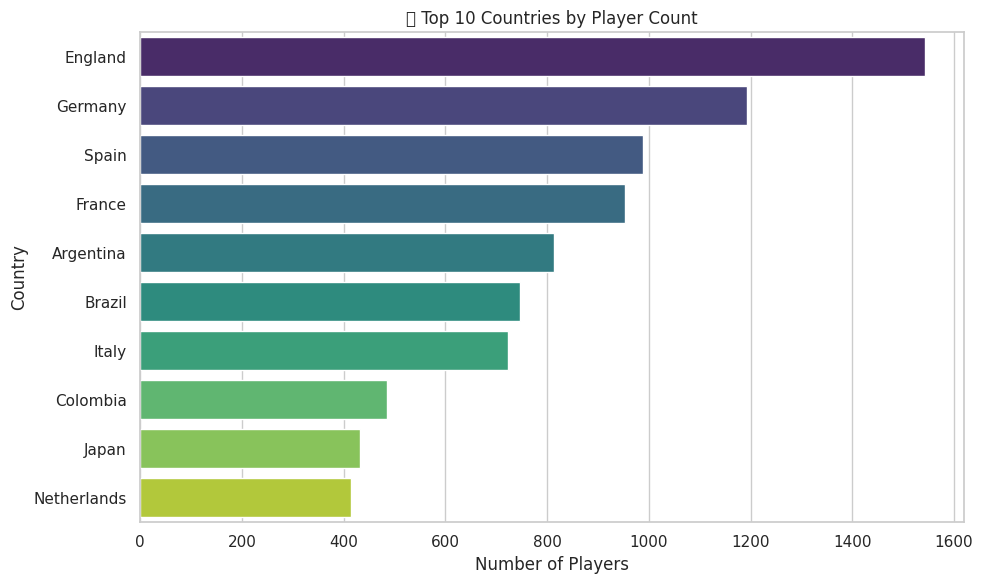

/tmp/ipython-input-147-3942259630.py:19: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


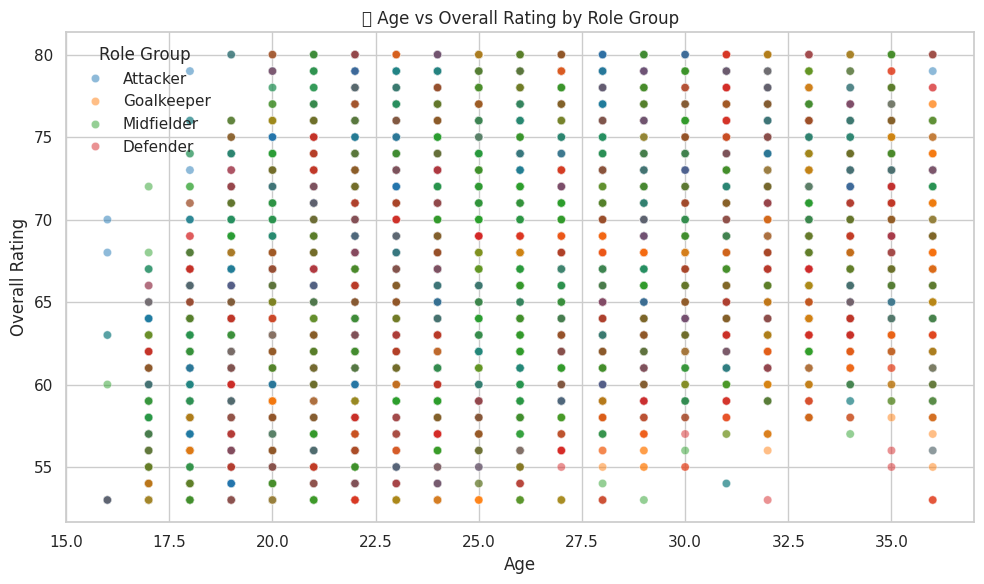

/tmp/ipython-input-147-3942259630.py:27: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


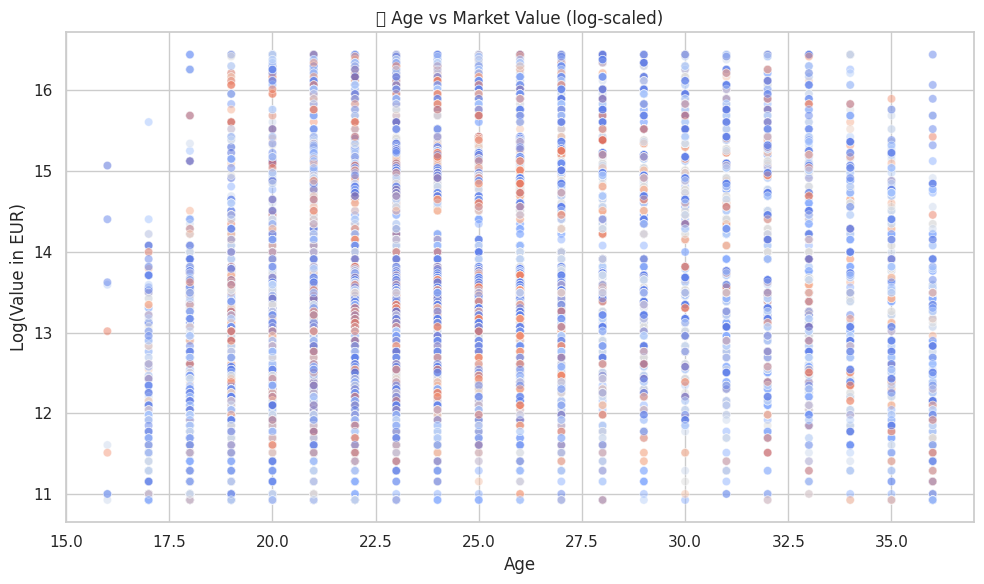

/tmp/ipython-input-147-3942259630.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='preferred_foot', data=df, palette='Set2')
/tmp/ipython-input-147-3942259630.py:35: UserWarning: Glyph 129462 (\N{FOOT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129462 (\N{FOOT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


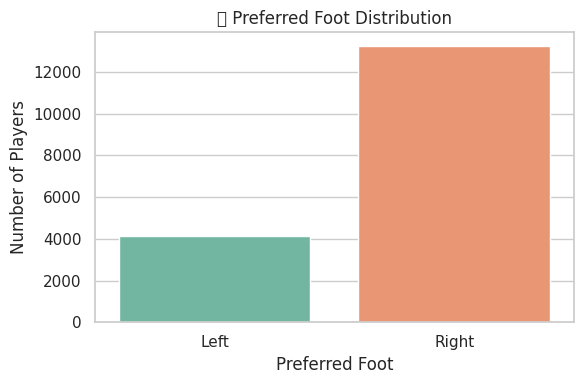

In [ ]:
# Set theme
sns.set(style='whitegrid')
# 🔹 Top 10 countries by player count
plt.figure(figsize=(10, 6))
top_countries = df['nationality'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('🌍 Top 10 Countries by Player Count')
plt.xlabel('Number of Players')
plt.ylabel('Country')
plt.tight_layout()
plt.show()
# 🔹 Age vs. Overall rating distribution
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='overall', hue='role_group', alpha=0.5, palette='tab10')
plt.title('🎯 Age vs Overall Rating by Role Group')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.legend(title='Role Group')
plt.tight_layout()
plt.show()
# 🔹 Age vs. log_value_eur
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='log_value_eur', hue='primary_position', alpha=0.5, palette='coolwarm', legend=False)
plt.title('💰 Age vs Market Value (log-scaled)')
plt.xlabel('Age')
plt.ylabel('Log(Value in EUR)')
plt.tight_layout()
plt.show()
# 🔹 Preferred Foot distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='preferred_foot', data=df, palette='Set2')
plt.title('🦶 Preferred Foot Distribution')
plt.xlabel('Preferred Foot')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()


#2: Positional Insights And Work Rate

## ⚽️ Posional & Tactical Dynamics
| Plot                                | Purpose                                                                   |
| ----------------------------------- | ------------------------------------------------------------------------- |
| 📌 **Role Group Distribution**      | Shows how players are spread across roles like Midfielder, Defender, etc. |
| 💸 **Boxplot of Value by Position** | Understand which positions are most valued                                |
| ⚙️ **Work Rate Combinations**       | Reveals common combinations of attacking/defensive work effort            |


/tmp/ipython-input-148-3107954985.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='role_group', data=df, palette='pastel')
/tmp/ipython-input-148-3107954985.py:7: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


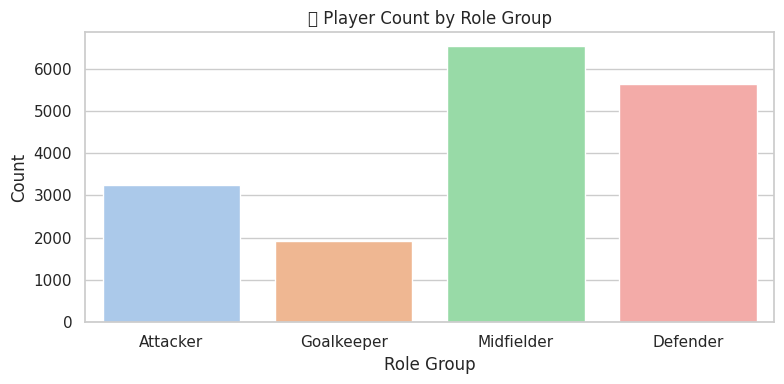

/tmp/ipython-input-148-3107954985.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['primary_position'].isin(top_positions)],
/tmp/ipython-input-148-3107954985.py:17: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


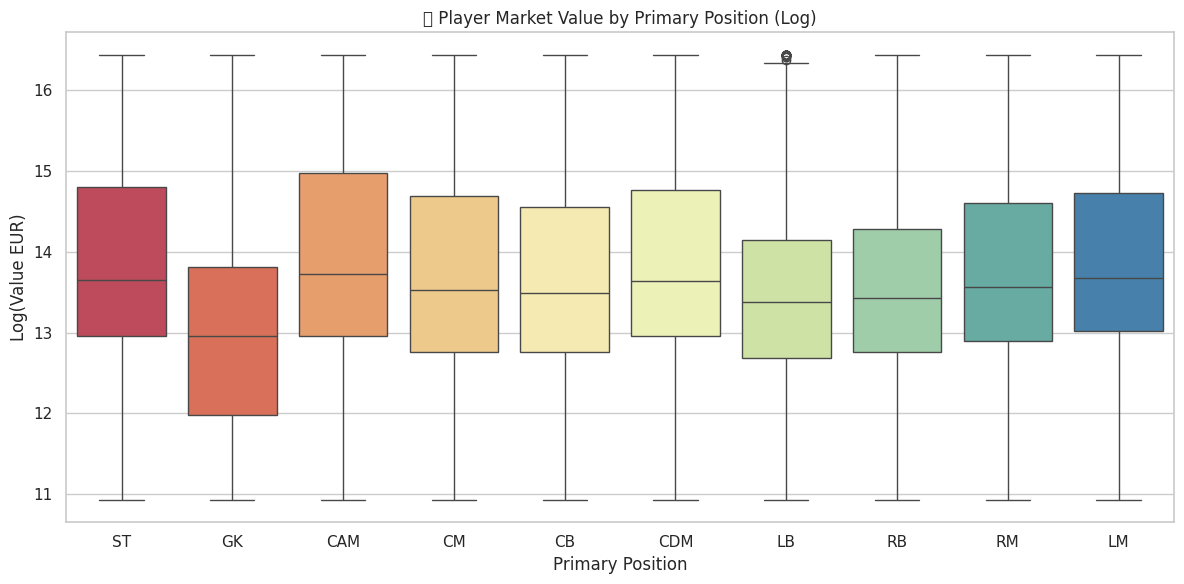

/tmp/ipython-input-148-3107954985.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_work_rates.index, y=top_work_rates.values, palette='Blues_d')


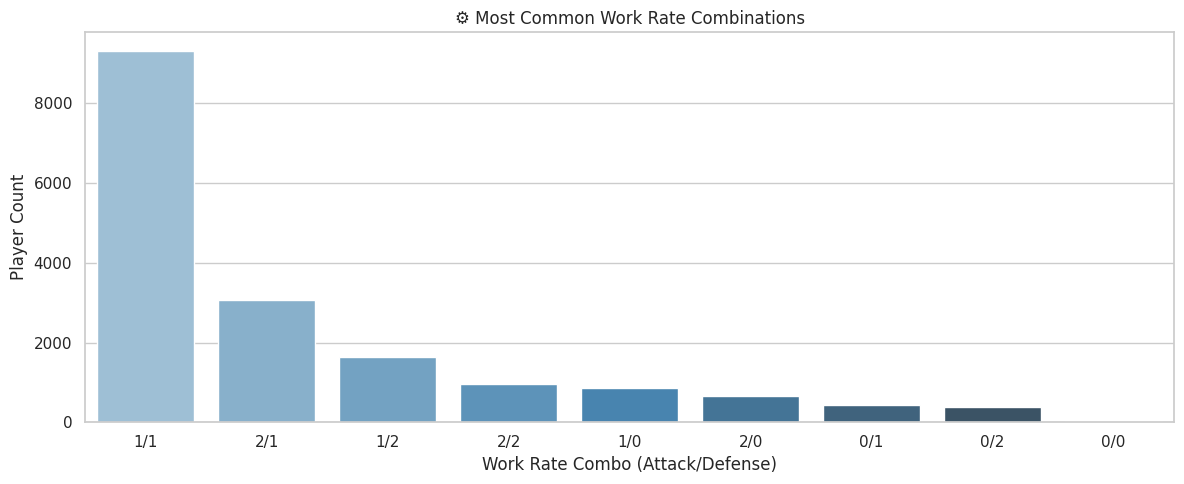

In [ ]:
# 🔹 Role Group Distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='role_group', data=df, palette='pastel')
plt.title('📌 Player Count by Role Group')
plt.xlabel('Role Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
# 🔹 Boxplot of Log Value by Position
plt.figure(figsize=(12, 6))
top_positions = df['primary_position'].value_counts().head(10).index
sns.boxplot(data=df[df['primary_position'].isin(top_positions)],
            x='primary_position', y='log_value_eur', palette='Spectral')
plt.title('💸 Player Market Value by Primary Position (Log)')
plt.xlabel('Primary Position')
plt.ylabel('Log(Value EUR)')
plt.tight_layout()
plt.show()
# 🔹 Work Rate combinations
df['work_rate_combo'] = df['attacking_work_rate'].astype(str) + '/' + df['defensive_work_rate'].astype(str)
plt.figure(figsize=(12, 5))
top_work_rates = df['work_rate_combo'].value_counts().head(10)
sns.barplot(x=top_work_rates.index, y=top_work_rates.values, palette='Blues_d')
plt.title('⚙️ Most Common Work Rate Combinations')
plt.xlabel('Work Rate Combo (Attack/Defense)')
plt.ylabel('Player Count')
plt.tight_layout()
plt.show()


#1: Global & Financial Insights

 ## 📊 Global & Financial Insights

 | No. | Plot Title                                  | Description                                                                |
| --- | ------------------------------------------- | -------------------------------------------------------------------------- |
| 1️⃣ | 🏟️ Top 10 Clubs by Number of Players       | Shows which clubs contribute the most players to the dataset.              |
| 2️⃣ | 💰 Top 10 Highest Paid Clubs (Avg. Wage)    | Highlights clubs that offer the highest average wage to their players.     |
| 3️⃣ | 💎 Top 10 Most Valuable Players (Log Scale) | Displays the 10 most expensive players based on market value (log scaled). |


/tmp/ipython-input-149-1450798517.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_wage_clubs.values, y=top_wage_clubs.index, palette="rocket")
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


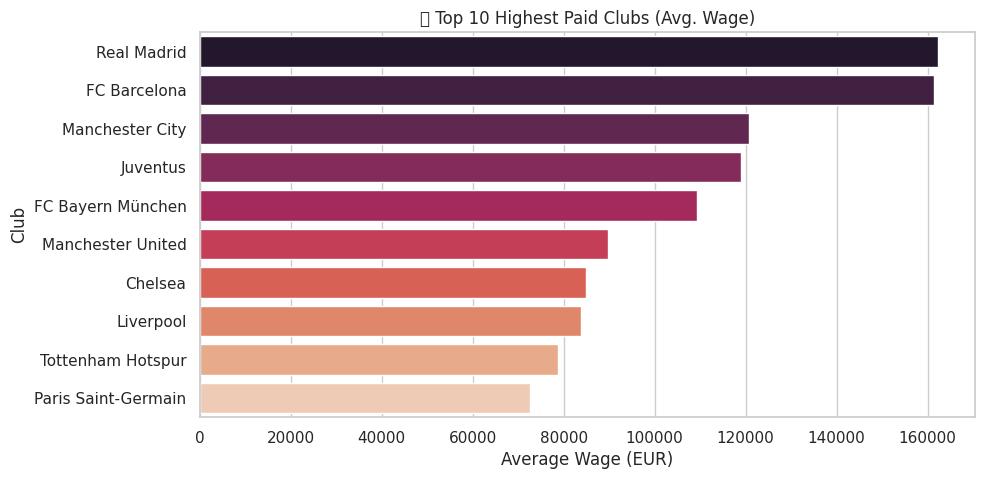

/tmp/ipython-input-149-1450798517.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='log_value_eur', y='short_name', data=top_value, palette="viridis")
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


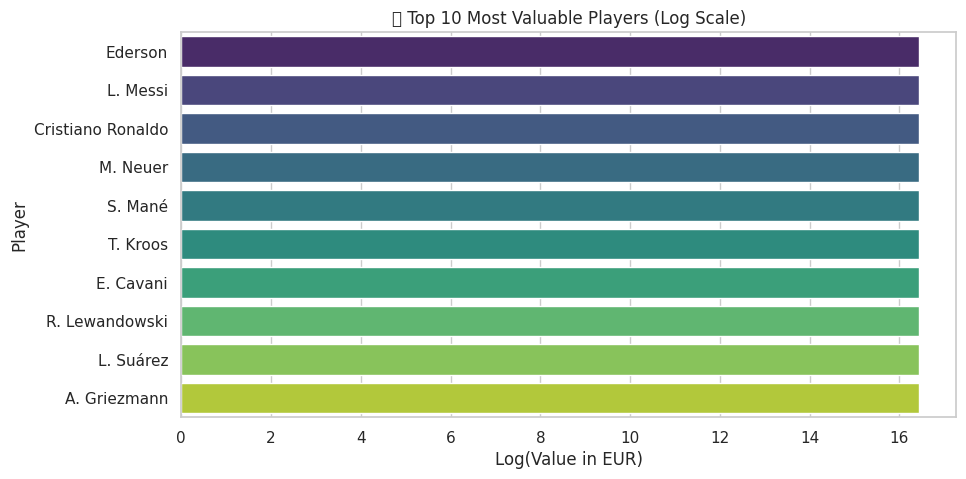

In [ ]:
# 🎯 2. Top 10 Clubs by Mean Wage
top_wage_clubs = df.groupby('club')['wage_eur'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_wage_clubs.values, y=top_wage_clubs.index, palette="rocket")
plt.title("💰 Top 10 Highest Paid Clubs (Avg. Wage)")
plt.xlabel("Average Wage (EUR)")
plt.ylabel("Club")
plt.show()
# 🎯 3. Top 10 Most Valuable Players
top_value = df[['short_name', 'log_value_eur']].sort_values(by='log_value_eur', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x='log_value_eur', y='short_name', data=top_value, palette="viridis")
plt.title("💎 Top 10 Most Valuable Players (Log Scale)")
plt.xlabel("Log(Value in EUR)")
plt.ylabel("Player")
plt.show()


#2.Skill, Role & Position Insights

##Skill, Role & Position Insights

| No. | Plot Title                                    | Description                                                                   |
| --- | --------------------------------------------- | ----------------------------------------------------------------------------- |
| 4️⃣ | 📊 Average Overall vs Potential by Role Group | Compares actual and expected performance across role types (e.g. Midfielder). |
| 5️⃣ | 📌 Player Count by Primary Position           | Shows distribution of players based on their main playing position.           |
| 6️⃣ | 💪 Physical Attributes by Role Group          | Examines strength, stamina, and jumping across different roles.               |


/tmp/ipython-input-150-1787833901.py:8: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 800x500 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


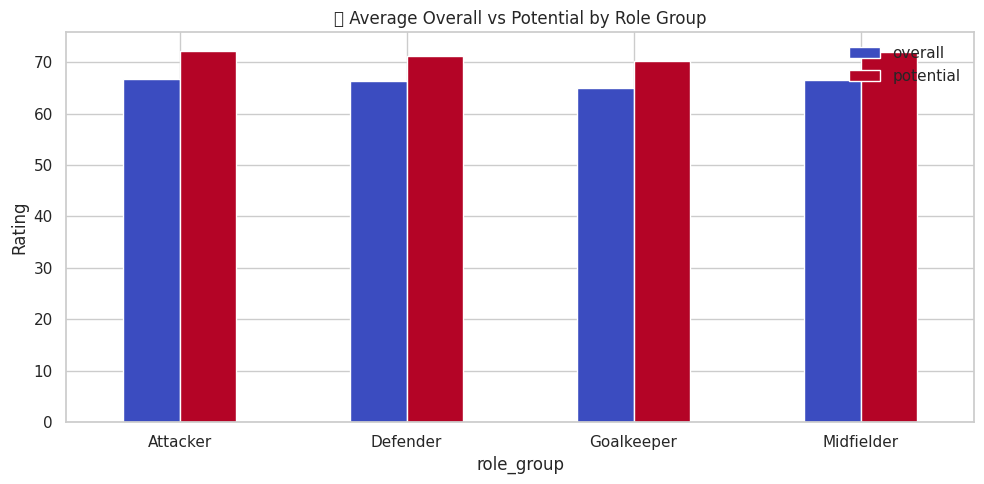

/tmp/ipython-input-150-1787833901.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='primary_position', order=df['primary_position'].value_counts().index, palette='Set2')
/tmp/ipython-input-150-1787833901.py:16: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


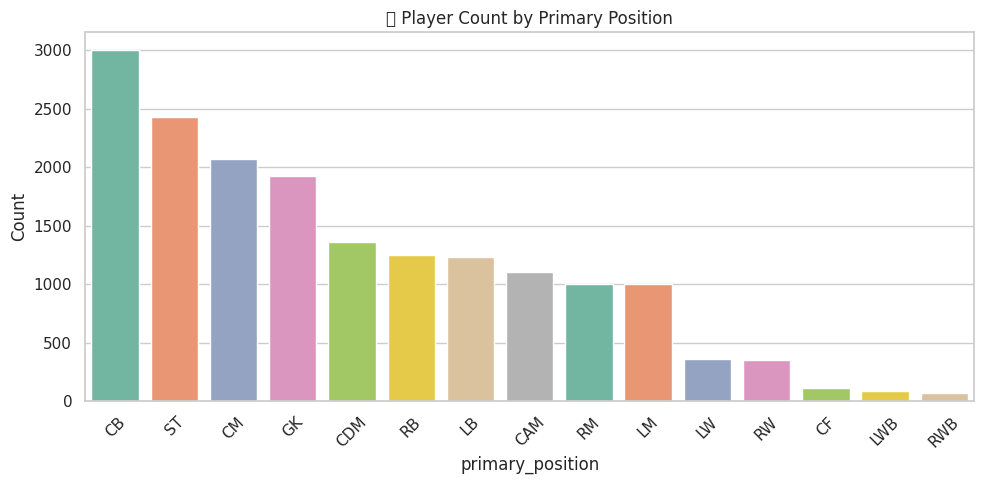

/tmp/ipython-input-150-1787833901.py:24: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


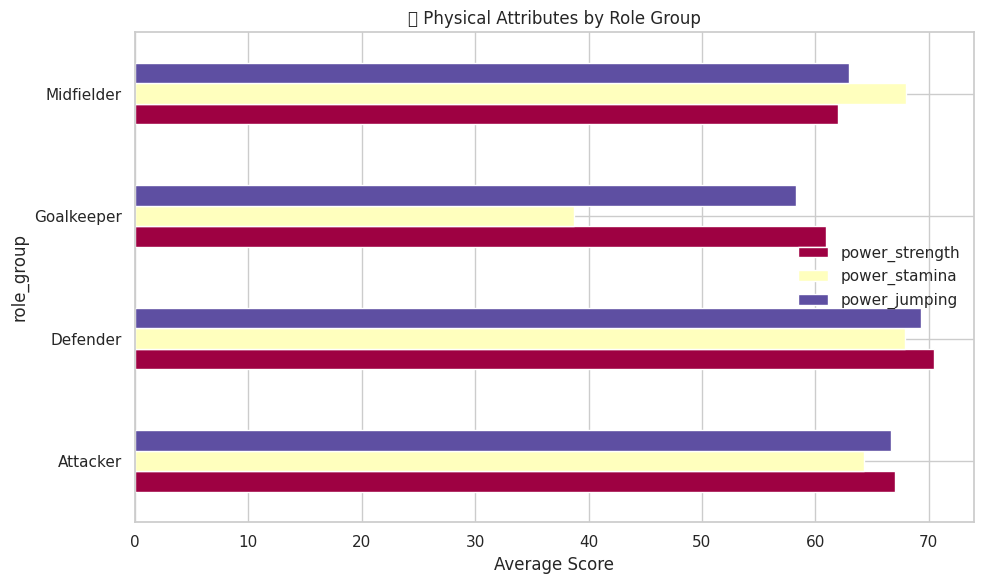

In [ ]:
# 🎯 4. Average Overall vs Potential by Role Group
plt.figure(figsize=(8, 5))
df.groupby('role_group')[['overall', 'potential']].mean().plot(kind='bar', figsize=(10, 5), colormap="coolwarm")
plt.title("📊 Average Overall vs Potential by Role Group")
plt.ylabel("Rating")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()
# 🎯 5. Distribution of Players per Primary Position
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='primary_position', order=df['primary_position'].value_counts().index, palette='Set2')
plt.title("📌 Player Count by Primary Position")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.tight_layout()
plt.show()
# 🎯 6. Average Physical Attributes by Role
physical_attrs = ['power_strength', 'power_stamina', 'power_jumping']
df_phys = df.groupby('role_group')[physical_attrs].mean().reset_index()
df_phys.set_index('role_group')[physical_attrs].plot(kind='barh', figsize=(10, 6), colormap="Spectral")
plt.title("💪 Physical Attributes by Role Group")
plt.xlabel("Average Score")
plt.tight_layout()
plt.show()

In [ ]:
# ✅ Save and download the cleaned dataset
from google.colab import files

df.to_csv("fifa20Post_EDA.csv", index=False)
files.download("fifa20Post_EDA.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.columns

Index(['short_name', 'age', 'height_cm', 'weight_kg', 'nationality', 'club',
       'overall', 'potential', 'value_eur', 'wage_eur',
       ...
       'RB', 'RM', 'RW', 'RWB', 'ST', 'tenure_years', 'log_value_eur',
       'log_wage_eur', 'log_release_clause_eur', 'work_rate_combo'],
      dtype='object', length=116)

In [ ]:
df.drop(columns=['work_rate_combo'])

,short_name,age,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,LWB,RB,RM,RW,RWB,ST,tenure_years,log_value_eur,log_wage_eur,log_release_clause_eur
0,L. Messi,32,170,72,Argentina,FC Barcelona,80,85,95500000,565000,...,0,0,0,1,0,1,8.0,16.442245,11.065889,16.755719
1,Cristiano Ronaldo,34,187,83,Portugal,Juventus,80,85,58500000,405000,...,0,0,0,0,0,1,4.0,16.442245,11.065889,16.755719
2,Neymar Jr,27,175,68,Brazil,Paris Saint-Germain,80,85,105500000,290000,...,0,0,0,0,0,0,5.0,16.442245,11.065889,16.755719
3,J. Oblak,26,188,87,Slovenia,Atlético Madrid,80,85,77500000,125000,...,0,0,0,0,0,0,8.0,16.442245,11.065889,16.755719
4,E. Hazard,28,175,74,Belgium,Real Madrid,80,85,90000000,470000,...,0,0,0,0,0,0,5.0,16.442245,11.065889,16.755719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17349,R. Wikberg,16,186,72,Sweden,Östersunds FK,53,67,50000,1000,...,0,0,0,0,0,0,3.0,10.927414,6.908755,11.606421
17350,E. Sartorius,16,174,69,England,Lincoln City,53,67,60000,1000,...,0,0,0,0,0,1,4.0,11.002117,6.908755,11.870607
17351,Wang Haijian,18,185,74,China PR,Shanghai Greenland Shenhua FC,53,58,40000,1000,...,0,0,0,0,0,0,3.0,10.927414,6.908755,11.606421
17352,M. Peck,18,175,66,England,Plymouth Argyle,53,68,60000,1000,...,0,0,0,0,0,0,2.0,11.002117,6.908755,12.013707


In [ ]:
df.shape

(17354, 116)